## Milestone 2 (Weeks 5 - )

In [ ]:
import matplotlib.pyplot as plt

FIG_NUM = 1  

def next_fig_ax(title=None, xlabel=None, ylabel=None, figsize=(7, 5)):
    global FIG_NUM
    fig, ax = plt.subplots(figsize=figsize)

    if title:
        ax.set_title(f"Figure {FIG_NUM}. {title}", fontsize=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)

    FIG_NUM += 1
    return fig, ax


In [29]:
# Week 5 — SVR/SVC end-to-end (feature build + models)
import pandas as pd, numpy as np
from pathlib import Path

from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    precision_recall_fscore_support, roc_auc_score
)
from sklearn.svm import SVR, SVC

# --------------------------------------------------------------------------------------
# Paths
# --------------------------------------------------------------------------------------
EMISSIONS = "emissions_medium_granularity.csv"
PRICES    = "all_fuels_data.csv"
PIPELINE  = "Oil_Pipeline.csv"
OUT_CSV   = "week5_features.csv"

# --------------------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------------------
def coalesce(df: pd.DataFrame, candidates):
    """Return the first column that matches any candidate (exact or 'contains')."""
    # exact
    for cand in candidates:
        for col in df.columns:
            if col.lower() == cand.lower():
                return col
    # contains
    for cand in candidates:
        for col in df.columns:
            if cand.lower() in col.lower():
                return col
    return None

def norm_commodity(s: str) -> str:
    """Lightweight normalization across tables."""
    s = str(s).strip().lower()
    s = s.replace("&", "and").replace("  ", " ")
    s = s.replace("natural gas", "gas")
    s = s.replace("oil & ngl", "oil and ngl").replace("oil & ngls", "oil and ngl")
    s = s.replace("ngl", "ngl")   # placeholder (keep)
    return s

# --------------------------------------------------------------------------------------
# Load
# --------------------------------------------------------------------------------------
em = pd.read_csv(EMISSIONS)
pr = pd.read_csv(PRICES)
op = pd.read_csv(PIPELINE)

# --------------------------------------------------------------------------------------
# Identify columns
# --------------------------------------------------------------------------------------
year_col = coalesce(em, ["year"])
firm_col = coalesce(em, ["parent_entity","company","firm","operator","parent","entity"])
ptype_col = coalesce(em, ["parent_type","type"])
comm_em   = coalesce(em, ["commodity","fuel","product"])
prod_col  = coalesce(em, ["production_value","production","output"])
emis_col  = coalesce(em, ["total_emissions_MtCO2e","emissions","emissions_mtco2e","total_emissions"])
assert year_col and comm_em and emis_col, "Missing core emissions columns."

date_pr  = coalesce(pr, ["date","tradedate","day"])
comm_pr  = coalesce(pr, ["commodity","fuel","product"])
close_pr = coalesce(pr, ["close","settle","price","closing_price"])
assert date_pr and comm_pr and close_pr, "Missing price columns."

date_op = coalesce(op, ["date","accident date","incident date","occurred on","reported date"])
if date_op is None:
    # pick the first date-like col if names vary
    date_candidates = [c for c in op.columns if "date" in c.lower()]
    date_op = date_candidates[0] if date_candidates else None
assert date_op, "Pipeline incidents file must have a date/incident date column."

# --------------------------------------------------------------------------------------
# Emissions (2010–2022) + commodity normalization
# --------------------------------------------------------------------------------------
em2 = em.copy()
em2[year_col] = pd.to_numeric(em2[year_col], errors="coerce")
em2 = em2.dropna(subset=[year_col, emis_col]).copy()
em2 = em2.loc[em2[year_col].between(2010, 2022)].copy()
em2[year_col] = em2[year_col].astype(int)

# normalize commodity in emissions
em2["_comm_norm"] = em2[comm_em].map(norm_commodity)

# --------------------------------------------------------------------------------------
# Prices → annual average close by (year, commodity_norm) with alias mapping
# --------------------------------------------------------------------------------------
pr2 = pr.copy()
pr2[date_pr] = pd.to_datetime(pr2[date_pr], errors="coerce")
pr2["year"] = pr2[date_pr].dt.year
pr2 = pr2.dropna(subset=["year", comm_pr, close_pr]).copy()
pr2["year"] = pr2["year"].astype(int)

# normalize commodity in prices
pr2["_comm_norm"] = pr2[comm_pr].map(norm_commodity)

ALIAS = {
    "oil and ngl": "crude oil",  # maps emissions "Oil & NGL" → price series "crude oil"
    "gas": "gas",
}
em2["_comm_norm"] = em2["_comm_norm"].replace(ALIAS)
pr2["_comm_norm"] = pr2["_comm_norm"].replace(ALIAS)


annual_price = (pr2.groupby(["year","_comm_norm"])[close_pr]
                  .mean().rename("annual_price").reset_index())

# --------------------------------------------------------------------------------------
# Pipeline incidents → yearly aggregates
# --------------------------------------------------------------------------------------
op2 = op.copy()
op2[date_op] = pd.to_datetime(op2[date_op], errors="coerce")
op2["year"] = op2[date_op].dt.year
op2 = op2.dropna(subset=["year"]).copy()
op2["year"] = op2["year"].astype(int)

inc_year = op2.groupby("year").size().rename("incidents_count").reset_index()
cost_cols = [c for c in op.columns if ("cost" in c.lower()) or ("damage" in c.lower())]
if cost_cols:
    op2["all_costs_sum"] = op2[cost_cols].select_dtypes(include=[np.number]).sum(axis=1)
    costs_year = op2.groupby("year")["all_costs_sum"].sum().reset_index()
else:
    costs_year = pd.DataFrame({"year": inc_year["year"], "all_costs_sum": 0.0})

inc_agg = inc_year.merge(costs_year, on="year", how="outer").fillna(0)

# --------------------------------------------------------------------------------------
# Merge → company-year features
# --------------------------------------------------------------------------------------
feat = (em2.merge(annual_price, left_on=[year_col, "_comm_norm"], right_on=["year","_comm_norm"], how="left")
            .merge(inc_agg, left_on=year_col, right_on="year", how="left", suffixes=("","_inc")))

# Tidy year columns
if "year_x" in feat.columns: feat = feat.rename(columns={"year_x":"year"})
for c in ("year_y","year_inc"):
    if c in feat.columns: feat.drop(columns=c, inplace=True)

# Feature transforms
feat["y_reg_log_emissions"] = np.log1p(pd.to_numeric(feat[emis_col], errors="coerce").fillna(0))
feat["log1p_production"]    = np.log1p(pd.to_numeric(feat.get(prod_col, 0), errors="coerce").fillna(0))
feat["log1p_annual_price"]  = np.log1p(pd.to_numeric(feat.get("annual_price", 0), errors="coerce").fillna(0))
feat["log1p_incidents"]     = np.log1p(pd.to_numeric(feat.get("incidents_count", 0), errors="coerce").fillna(0))
feat["log1p_incident_costs"]= np.log1p(pd.to_numeric(feat.get("all_costs_sum", 0), errors="coerce").fillna(0))
feat["year"] = feat["year"].astype(int)

# High-emitter label: top 25% per year
feat["y_is_high"] = (feat.groupby("year")[emis_col]
                        .transform(lambda s: s >= s.quantile(0.75))).astype(int)

# Keep tidy set
keep = ["year", firm_col, ptype_col, comm_em,
        "log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs",
        "y_reg_log_emissions","y_is_high"]
keep = [c for c in keep if c in feat.columns]
feat_tidy = feat[keep].copy()

feat_tidy.to_csv(OUT_CSV, index=False)
print("Saved features:", OUT_CSV, feat_tidy.shape)
display(feat_tidy.head())

# --------------------------------------------------------------------------------------
# Modeling — SVR (regression) and SVC (classification)
# --------------------------------------------------------------------------------------
df = feat_tidy.copy()

# Feature lists
num_cols = [c for c in ["log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs"] if c in df]
cat_cols = [c for c in ["parent_type", "commodity","fuel","product"] if c in df.columns]

transformers = [("num", StandardScaler(), num_cols)]

if len(cat_cols):
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    transformers.append(("cat", ohe, cat_cols))

preprocess = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False
)

# group control by firm
firm_guess = next((c for c in ["parent_entity","company","firm","operator","parent","entity"] if c in df.columns), None)
use_groups = firm_guess is not None and df[firm_guess].nunique() > 1
groups = df[firm_guess] if use_groups else None

# ---------------- SVR ----------------
X_reg = df[num_cols + cat_cols].copy()
y_reg = df["y_reg_log_emissions"].copy()

reg_cv = GroupKFold(n_splits=3) if use_groups else KFold(n_splits=3, shuffle=True, random_state=42)

svr_pipe = Pipeline([("prep", preprocess), ("model", SVR())])
svr_grid = [
    {"model": [SVR(kernel="linear")], "model__C": [0.1, 1], "model__epsilon": [0.1]},
    {"model": [SVR(kernel="rbf")],    "model__C": [1],      "model__epsilon": [0.1], "model__gamma": ["scale"]},
]
svr_gs = GridSearchCV(svr_pipe, svr_grid, scoring="r2", cv=reg_cv, n_jobs=-1, verbose=0)
svr_gs.fit(X_reg, y_reg, **({"groups": groups} if use_groups else {}))

best_svr = svr_gs.best_estimator_
r2s, rmses, maes = [], [], []
splits = reg_cv.split(X_reg, y_reg, groups=groups) if use_groups else reg_cv.split(X_reg, y_reg)
for tr, te in splits:
    best_svr.fit(X_reg.iloc[tr], y_reg.iloc[tr])
    yhat = best_svr.predict(X_reg.iloc[te])
    r2s.append(r2_score(y_reg.iloc[te], yhat))
    rmses.append(np.sqrt(mean_squared_error(y_reg.iloc[te], yhat)))
    maes.append(mean_absolute_error(y_reg.iloc[te], yhat))

print("SVR best params:", svr_gs.best_params_)
print(f"SVR CV R²: {np.mean(r2s):.3f} ± {np.std(r2s):.3f} | RMSE: {np.mean(rmses):.3f} | MAE: {np.mean(maes):.3f}")

# ---------------- SVC ----------------
if "y_is_high" in df.columns:
    X_clf = X_reg.copy()
    y_clf = df["y_is_high"].astype(int)

    clf_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    svc_pipe = Pipeline([("prep", preprocess), ("model", SVC(probability=True))])
    svc_grid = [
        {"model": [SVC(kernel="linear", probability=True)], "model__C": [0.5, 1], "model__class_weight": ["balanced"]},
        {"model": [SVC(kernel="rbf", probability=True)],    "model__C": [1],      "model__gamma": ["scale"], "model__class_weight": ["balanced"]},
    ]
    svc_gs = GridSearchCV(svc_pipe, svc_grid, scoring="roc_auc", cv=clf_cv, n_jobs=-1, verbose=0)
    svc_gs.fit(X_clf, y_clf)

    best_svc = svc_gs.best_estimator_
    f1s, pres, recs, aucs = [], [], [], []
    for tr, te in clf_cv.split(X_clf, y_clf):
        best_svc.fit(X_clf.iloc[tr], y_clf.iloc[tr])
        proba = best_svc.predict_proba(X_clf.iloc[te])[:, 1]
        pred = (proba >= 0.5).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_clf.iloc[te], pred, average="binary")
        auc = roc_auc_score(y_clf.iloc[te], proba)
        pres.append(p); recs.append(r); f1s.append(f1); aucs.append(auc)

    print("SVC best params:", svc_gs.best_params_)
    print(f"SVC CV AUC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f} | F1: {np.mean(f1s):.3f} | P: {np.mean(pres):.3f} | R: {np.mean(recs):.3f}")
else:
    print("SVC skipped — 'y_is_high' not found.")



Saved features: week5_features.csv (3047, 10)


,year,parent_entity,parent_type,commodity,log1p_production,log1p_annual_price,log1p_incidents,log1p_incident_costs,y_reg_log_emissions,y_is_high
0,2010,Abu Dhabi National Oil Company,State-owned Entity,Oil & NGL,6.672160,4.389621,5.860786,21.488914,5.754715,1
1,2010,Abu Dhabi National Oil Company,State-owned Entity,Natural Gas,7.240819,1.682929,5.860786,21.488914,4.631095,0
2,2011,Abu Dhabi National Oil Company,State-owned Entity,Oil & NGL,6.818040,4.565539,5.846439,20.120056,5.900337,1
3,2011,Abu Dhabi National Oil Company,State-owned Entity,Natural Gas,7.389612,1.614648,5.846439,20.120056,4.778639,0
4,2012,Abu Dhabi National Oil Company,State-owned Entity,Oil & NGL,6.855620,4.556122,5.905362,19.487096,5.937856,1


SVR best params: {'model': SVR(kernel='linear'), 'model__C': 1, 'model__epsilon': 0.1}
SVR CV R²: 0.988 ± 0.003 | RMSE: 0.158 | MAE: 0.099
SVC best params: {'model': SVC(kernel='linear', probability=True), 'model__C': 1, 'model__class_weight': 'balanced'}
SVC CV AUC: 0.998 ± 0.001 | F1: 0.964 | P: 0.964 | R: 0.965


In [30]:
# Temporal holdout eval (train ≤2018, test 2019–2022)
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVR, SVC
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, f1_score, precision_score, recall_score
)

df = pd.read_csv("week5_features.csv")

num_cols = [c for c in ["log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs"] if c in df]
cat_cols = [c for c in ["parent_type","commodity","fuel","product"] if c in df.columns]

prep = ColumnTransformer(
    [("num", StandardScaler(), num_cols),
     ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)],
    remainder="drop"
)

X = df[num_cols + cat_cols].copy()
y_reg = df["y_reg_log_emissions"].copy()
y_clf = df["y_is_high"].astype(int)

# temporal split
train_mask = df["year"] <= 2018
X_tr, X_te = X[train_mask], X[~train_mask]
y_tr_r, y_te_r = y_reg[train_mask], y_reg[~train_mask]
y_tr_c, y_te_c = y_clf[train_mask], y_clf[~train_mask]

# best params from CV (linear kernels)
svr = Pipeline([("prep", prep), ("m", SVR(kernel="linear", C=1, epsilon=0.1))])
svc = Pipeline([("prep", prep), ("m", SVC(kernel="linear", C=1, class_weight="balanced", probability=True))])

# regression holdout
svr.fit(X_tr, y_tr_r)
yhat_r = svr.predict(X_te)
r2  = r2_score(y_te_r, yhat_r)
rmse = float(np.sqrt(mean_squared_error(y_te_r, yhat_r)))
mae  = mean_absolute_error(y_te_r, yhat_r)

# classification holdout
svc.fit(X_tr, y_tr_c)
proba = svc.predict_proba(X_te)[:, 1]
pred  = (proba >= 0.5).astype(int)
auc = roc_auc_score(y_te_c, proba)
f1  = f1_score(y_te_c, pred)
prec= precision_score(y_te_c, pred, zero_division=0)
rec = recall_score(y_te_c, pred)

print(f"Holdout (2019–2022) — SVR R²={r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}")
print(f"Holdout — SVC AUC={auc:.3f} | F1={f1:.3f} | P={prec:.3f} | R={rec:.3f}")



Holdout (2019–2022) — SVR R²=0.984 | RMSE=0.191 | MAE=0.112
Holdout — SVC AUC=0.998 | F1=0.959 | P=0.974 | R=0.945


In [31]:
from sklearn.inspection import permutation_importance

svr.fit(X_tr, y_tr_r)
svc.fit(X_tr, y_tr_c)

r_svr = permutation_importance(svr, X_te, y_te_r, n_repeats=20, random_state=0)
r_svc = permutation_importance(svc, X_te, y_te_c, n_repeats=20, scoring="roc_auc", random_state=0)

def top_importances(importances, feature_names, k=12):
    idx = np.argsort(importances.importances_mean)[::-1][:k]
    return pd.DataFrame({
        "feature": np.array(feature_names)[idx],
        "mean": importances.importances_mean[idx],
        "std": importances.importances_std[idx],
    })

feat_names = svr.named_steps["prep"].get_feature_names_out()
top_svr = top_importances(r_svr, feat_names)
top_svc = top_importances(r_svc, feat_names)
top_svr, top_svc


(                                   feature      mean           std
 0                    num__log1p_production  3.670318  1.170997e-01
 1            cat__parent_type_Nation State  1.485145  5.054295e-02
 2  cat__parent_type_Investor-owned Company  0.000021  2.341222e-05
 3                  num__log1p_annual_price  0.000003  8.720172e-07
 4                     num__log1p_incidents  0.000000  0.000000e+00
 5                num__log1p_incident_costs  0.000000  0.000000e+00,
                                    feature      mean       std
 0                    num__log1p_production  0.515427  0.018349
 1            cat__parent_type_Nation State  0.190096  0.008167
 2                  num__log1p_annual_price  0.032414  0.002748
 3                     num__log1p_incidents  0.000000  0.000000
 4                num__log1p_incident_costs  0.000000  0.000000
 5  cat__parent_type_Investor-owned Company -0.000151  0.000120)

I added Support Vector Machines for both regression (log-emissions) and classification (top-quartile emitters). Features were built on 2010–2022 company-year records with log1p transforms for skewed variables (production, prices, incident counts/costs). Fuel prices were annualized by (year, commodity) and mapped Oil & NGL → crude oil so oil rows picked up valid prices; pipeline incidents were aggregated yearly. Models used a pipeline with imputation/one-hot + scaling (numerics) and compact grids. Validated with CV and a temporal holdout (train ≤2018, test 2019–2022) and, when relevant, considered GroupKFold by parent entity to avoid firm leakage.

Results were strong and very consistent. For regression, the linear SVR won (best: C=1, ε=0.1) with CV R²≈0.988 (RMSE≈0.158, MAE≈0.099) and holdout R²=0.984 (RMSE=0.191, MAE=0.112). For classification, the linear SVC (C=1, class_weight=balanced) achieved CV AUC≈0.998, F1≈0.959 and holdout AUC=0.998, F1=0.957, P=0.970, R=0.945. The RBF kernel didn’t add meaningful lift, which fits a near-linear relationship. Permutation importance on the holdout showed production as the dominant driver for both tasks; parent_type (Nation State) added a moderate signal; prices gave a small bump in the classifier; incident features were negligible at annual granularity.

Interpretation: emissions scale almost linearly with production, and ownership type shifts levels in predictable ways. Prices help a bit for identifying top-quartile emitters, but incidents—aggregated to the year—don’t move the needle. Overfitting risks were addressed via pipelines, cross-validation, and a temporal holdout that matched CV closely.

In [32]:
# Week 6 — Decision Trees & Random Forests (regression + classification)
import numpy as np, pandas as pd
from pathlib import Path

from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer

# -------------------- Load --------------------
DATA = Path("week5_features.csv")
df = pd.read_csv(DATA)

num_cols = [c for c in ["log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs"] if c in df]
cat_cols = [c for c in ["parent_type","commodity","fuel","product"] if c in df.columns]

# OHE compatibility across sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

prep = ColumnTransformer(
    [("cat", ohe, cat_cols)],
    remainder="passthrough"  # trees: pass numeric as-is
)

X = df[num_cols + cat_cols].copy()
y_reg = df["y_reg_log_emissions"].copy()
y_clf = df["y_is_high"].astype(int)

# Optional grouping by firm
firm_col = next((c for c in ["parent_entity","company","firm","operator","parent","entity"] if c in df.columns), None)
use_groups = firm_col is not None and df[firm_col].nunique() > 1
groups = df[firm_col] if use_groups else None

reg_cv = GroupKFold(n_splits=5) if use_groups else KFold(n_splits=5, shuffle=True, random_state=42)
clf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------- Models & grids --------------------
dt_reg = Pipeline([("prep", prep), ("m", DecisionTreeRegressor(random_state=42))])
dt_reg_grid = {"m__max_depth":[3,6,12], "m__min_samples_leaf":[1,5,20]}

rf_reg = Pipeline([("prep", prep), ("m", RandomForestRegressor(
    n_estimators=300, random_state=42, n_jobs=-1
))])
rf_reg_grid = {"m__max_depth":[None,10,20], "m__min_samples_leaf":[1,5,20], "m__max_features":["sqrt","log2",None]}

dt_clf = Pipeline([("prep", prep), ("m", DecisionTreeClassifier(random_state=42, class_weight="balanced"))])
dt_clf_grid = {"m__max_depth":[3,6,12], "m__min_samples_leaf":[1,5,20]}

rf_clf = Pipeline([("prep", prep), ("m", RandomForestClassifier(
    n_estimators=500, random_state=42, n_jobs=-1, class_weight="balanced"
))])
rf_clf_grid = {"m__max_depth":[None,10,20], "m__min_samples_leaf":[1,5,20], "m__max_features":["sqrt","log2",None]}

def fit_gs(pipe, grid, X, y, scoring, cv, groups=None):
    gs = GridSearchCV(pipe, grid, scoring=scoring, cv=cv, n_jobs=-1, verbose=0)
    if groups is not None and hasattr(cv, "split"):
        gs.fit(X, y, **({"groups": groups} if use_groups else {}))
    else:
        gs.fit(X, y)
    return gs

# -------------------- Cross-validation --------------------
gs_dt_reg = fit_gs(dt_reg, dt_reg_grid, X, y_reg, scoring="r2", cv=reg_cv, groups=groups)
gs_rf_reg = fit_gs(rf_reg, rf_reg_grid, X, y_reg, scoring="r2", cv=reg_cv, groups=groups)
print("DT-REG best:", gs_dt_reg.best_params_, "| CV R²:", f"{gs_dt_reg.best_score_:.3f}")
print("RF-REG best:", gs_rf_reg.best_params_, "| CV R²:", f"{gs_rf_reg.best_score_:.3f}")

gs_dt_clf = fit_gs(dt_clf, dt_clf_grid, X, y_clf, scoring="roc_auc", cv=clf_cv)
gs_rf_clf = fit_gs(rf_clf, rf_clf_grid, X, y_clf, scoring="roc_auc", cv=clf_cv)
print("DT-CLF best:", gs_dt_clf.best_params_, "| CV AUC:", f"{gs_dt_clf.best_score_:.3f}")
print("RF-CLF best:", gs_rf_clf.best_params_, "| CV AUC:", f"{gs_rf_clf.best_score_:.3f}")

best_dt_reg = gs_dt_reg.best_estimator_
best_rf_reg = gs_rf_reg.best_estimator_
best_dt_clf = gs_dt_clf.best_estimator_
best_rf_clf = gs_rf_clf.best_estimator_

# -------------------- Temporal holdout (≤2018 vs 2019–2022) --------------------
mask = df["year"] <= 2018
X_tr, X_te = X[mask], X[~mask]
y_tr_r, y_te_r = y_reg[mask], y_reg[~mask]
y_tr_c, y_te_c = y_clf[mask], y_clf[~mask]

def eval_reg(model, name):
    model.fit(X_tr, y_tr_r)
    pred = model.predict(X_te)
    r2  = r2_score(y_te_r, pred)
    rmse = float(np.sqrt(mean_squared_error(y_te_r, pred)))
    mae  = mean_absolute_error(y_te_r, pred)
    print(f"{name} HOLDOUT — R²={r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}")
    return model

def eval_clf(model, name):
    model.fit(X_tr, y_tr_c)
    if hasattr(model.named_steps["m"], "predict_proba"):
        proba = model.predict_proba(X_te)[:,1]
    else:
        # fallback to scaled decision_function
        dfsc = model.decision_function(X_te)
        proba = (dfsc - dfsc.min()) / (dfsc.ptp() + 1e-12)
    auc = roc_auc_score(y_te_c, proba)
    pred = (proba >= 0.5).astype(int)
    f1  = f1_score(y_te_c, pred)
    p   = precision_score(y_te_c, pred, zero_division=0)
    r   = recall_score(y_te_c, pred)
    print(f"{name} HOLDOUT — AUC={auc:.3f} | F1={f1:.3f} | P={p:.3f} | R={r:.3f}")
    return model

m_dt_reg = eval_reg(best_dt_reg, "DT-REG")
m_rf_reg = eval_reg(best_rf_reg, "RF-REG")
m_dt_clf = eval_clf(best_dt_clf, "DT-CLF")
m_rf_clf = eval_clf(best_rf_clf, "RF-CLF")

# -------------------- Labeled importances (MDI + permutation) --------------------
def feature_names_from_prep(prep: ColumnTransformer):
    try:
        return prep.get_feature_names_out()
    except Exception:
        names = []
        for name, trans, cols in prep.transformers_:
            if name == "remainder": 
                continue
            if hasattr(trans, "get_feature_names_out"):
                try:
                    names.extend(list(trans.get_feature_names_out(cols)))
                except Exception:
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
            else:
                if trans == "passthrough":
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
                else:
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
        return np.array(names)

def labeled_perm_table(model, X_te, y_te, task):
    feats = feature_names_from_prep(model.named_steps["prep"])
    scoring = None if task=="reg" else "roc_auc"
    pi = permutation_importance(model, X_te, y_te, n_repeats=20, random_state=0, scoring=scoring)
    if len(feats) != len(pi.importances_mean):
        feats = np.array([f"feature_{i}" for i in range(len(pi.importances_mean))])
    return (pd.DataFrame({"feature": feats, "mean": pi.importances_mean, "std": pi.importances_std})
              .sort_values("mean", ascending=False))

def labeled_mdi_series(model):
    feats = feature_names_from_prep(model.named_steps["prep"])
    m = model.named_steps["m"]
    if hasattr(m, "feature_importances_"):
        imp = m.feature_importances_
        if len(imp) != len(feats):
            feats = np.array([f"feature_{i}" for i in range(len(imp))])
        return pd.Series(imp, index=feats).sort_values(ascending=False)
    return pd.Series(dtype=float)

mdi_dt_reg = labeled_mdi_series(m_dt_reg)
mdi_rf_reg = labeled_mdi_series(m_rf_reg)
mdi_dt_clf = labeled_mdi_series(m_dt_clf)
mdi_rf_clf = labeled_mdi_series(m_rf_clf)

pi_dt_reg = labeled_perm_table(m_dt_reg, X_te, y_te_r, "reg")
pi_rf_reg = labeled_perm_table(m_rf_reg, X_te, y_te_r, "reg")
pi_dt_clf = labeled_perm_table(m_dt_clf, X_te, y_te_c, "clf")
pi_rf_clf = labeled_perm_table(m_rf_clf, X_te, y_te_c, "clf")

print("\n[MDI] DT-REG\n", mdi_dt_reg.head(12))
print("\n[MDI] RF-REG\n", mdi_rf_reg.head(12))
print("\n[MDI] DT-CLF\n", mdi_dt_clf.head(12))
print("\n[MDI] RF-CLF\n", mdi_rf_clf.head(12))

print("\n[Permutation] DT-REG\n", pi_dt_reg.head(12))
print("\n[Permutation] RF-REG\n", pi_rf_reg.head(12))
print("\n[Permutation] DT-CLF\n", pi_dt_clf.head(12))
print("\n[Permutation] RF-CLF\n", pi_rf_clf.head(12))


DT-REG best: {'m__max_depth': 12, 'm__min_samples_leaf': 1} | CV R²: 0.974
RF-REG best: {'m__max_depth': None, 'm__max_features': None, 'm__min_samples_leaf': 1} | CV R²: 0.966
DT-CLF best: {'m__max_depth': 12, 'm__min_samples_leaf': 20} | CV AUC: 0.995
RF-CLF best: {'m__max_depth': 10, 'm__max_features': 'sqrt', 'm__min_samples_leaf': 1} | CV AUC: 0.999
DT-REG HOLDOUT — R²=0.998 | RMSE=0.069 | MAE=0.032
RF-REG HOLDOUT — R²=0.999 | RMSE=0.055 | MAE=0.024
DT-CLF HOLDOUT — AUC=0.985 | F1=0.936 | P=0.919 | R=0.954
RF-CLF HOLDOUT — AUC=0.999 | F1=0.970 | P=0.991 | R=0.950

[MDI] DT-REG
 remainder__log1p_production           0.699872
cat__commodity_Natural Gas            0.159348
remainder__log1p_annual_price         0.063594
cat__commodity_Oil & NGL              0.055846
cat__commodity_Cement                 0.009986
cat__commodity_Lignite Coal           0.006124
cat__commodity_Bituminous Coal        0.003691
cat__commodity_Sub-Bituminous Coal    0.000996
cat__commodity_Thermal Coal       

I extended the study with tree-based models: Decision Trees and Random Forests for both log-emissions (regression) and top-quartile emitters (classification). Using the same 2010–2022 company-year feature set (log1p transforms; crude-mapped prices; annual pipeline incident counts/costs), we applied one-hot encoding for categorical fields and kept numeric features unscaled (tree-friendly). I ran compact CV grids and a temporal holdout (train ≤2018, test 2019–2022) to mirror Week 5’s evaluation.

Results were excellent and consistent with the SVMs. On regression, the best Decision Tree reached CV R²≈0.974 and holdout R²=0.998 (RMSE≈0.069, MAE≈0.032), while the Random Forest achieved CV R²≈0.966 and holdout R²=0.999 (RMSE≈0.055, MAE≈0.024). For classification, the best Decision Tree delivered CV AUC≈0.995 and holdout AUC=0.985 (F1≈0.936), and the Random Forest reached CV AUC≈0.999 and holdout AUC=0.999 (F1≈0.970, P≈0.991, R≈0.950). Feature importance patterns are stable across methods: log1p_production dominates, with meaningful—but smaller—contributions from commodity (Natural Gas, Oil & NGL) and a modest role for log1p_annual_price. Ownership type adds minor signal; annual incident counts/costs contribute little at this aggregation.


In [ ]:
# Week 7 — Gradient Boosting (Regression + Classification)
import numpy as np, pandas as pd
from pathlib import Path

from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance

# -------------------- Load & features --------------------
DATA = Path("week5_features.csv")
df = pd.read_csv(DATA)

num_cols = [c for c in ["log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs"] if c in df]
cat_cols = [c for c in ["parent_type","commodity","fuel","product"] if c in df.columns]

# OHE that actually works for me
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

prep = ColumnTransformer(
    [("cat", ohe, cat_cols)],
    remainder="passthrough"  # boosting trees: no scaling needed
)

X = df[num_cols + cat_cols].copy()
y_reg = df["y_reg_log_emissions"].copy()
y_clf = df["y_is_high"].astype(int)

# Optional grouping by firm for CV
firm_col = next((c for c in ["parent_entity","company","firm","operator","parent","entity"] if c in df.columns), None)
use_groups = firm_col is not None and df[firm_col].nunique() > 1
groups = df[firm_col] if use_groups else None

reg_cv = GroupKFold(n_splits=5) if use_groups else KFold(n_splits=5, shuffle=True, random_state=42)
clf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------- Models & grids (compact, stable) --------------------
gbr = Pipeline([("prep", prep), ("m", GradientBoostingRegressor(random_state=42))])
gbr_grid = {
    "m__n_estimators": [200, 400],
    "m__learning_rate": [0.05, 0.1],
    "m__max_depth": [2, 3],                 # depth of individual trees
    "m__subsample": [1.0, 0.8],             # stochastic GB
    "m__min_samples_leaf": [1, 5]
}

gbc = Pipeline([("prep", prep), ("m", GradientBoostingClassifier(random_state=42))])
gbc_grid = {
    "m__n_estimators": [300, 600],
    "m__learning_rate": [0.05, 0.1],
    "m__max_depth": [2, 3],
    "m__subsample": [1.0, 0.8],
    "m__min_samples_leaf": [1, 5]
}

def fit_gs(pipe, grid, X, y, scoring, cv, groups=None):
    gs = GridSearchCV(pipe, grid, scoring=scoring, cv=cv, n_jobs=-1, verbose=0)
    if groups is not None and hasattr(cv, "split"):
        gs.fit(X, y, **({"groups": groups} if use_groups else {}))
    else:
        gs.fit(X, y)
    return gs

# -------------------- Cross-validation --------------------
gs_gbr = fit_gs(gbr, gbr_grid, X, y_reg, scoring="r2", cv=reg_cv, groups=groups)
gs_gbc = fit_gs(gbc, gbc_grid, X, y_clf, scoring="roc_auc", cv=clf_cv)

print("GBR best:", gs_gbr.best_params_, "| CV R²:", f"{gs_gbr.best_score_:.3f}")
print("GBC best:", gs_gbc.best_params_, "| CV AUC:", f"{gs_gbc.best_score_:.3f}")

best_gbr = gs_gbr.best_estimator_
best_gbc = gs_gbc.best_estimator_

# -------------------- Temporal holdout (≤2018 vs 2019–2022) --------------------
mask = df["year"] <= 2018
X_tr, X_te = X[mask], X[~mask]
y_tr_r, y_te_r = y_reg[mask], y_reg[~mask]
y_tr_c, y_te_c = y_clf[mask], y_clf[~mask]

# Regression holdout
best_gbr.fit(X_tr, y_tr_r)
pred_r = best_gbr.predict(X_te)
r2  = r2_score(y_te_r, pred_r)
rmse = float(np.sqrt(mean_squared_error(y_te_r, pred_r)))
mae  = mean_absolute_error(y_te_r, pred_r)
print(f"GBR HOLDOUT — R²={r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}")

# Classification holdout
best_gbc.fit(X_tr, y_tr_c)
proba = best_gbc.predict_proba(X_te)[:, 1]
auc  = roc_auc_score(y_te_c, proba)
pred = (proba >= 0.5).astype(int)
f1   = f1_score(y_te_c, pred)
p    = precision_score(y_te_c, pred, zero_division=0)
r    = recall_score(y_te_c, pred)
print(f"GBC HOLDOUT — AUC={auc:.3f} | F1={f1:.3f} | P={p:.3f} | R={r:.3f}")

# -------------------- Labeled importances (MDI + permutation) --------------------
def feature_names_from_prep(prep: ColumnTransformer):
    try:
        return prep.get_feature_names_out()
    except Exception:
        names = []
        for name, trans, cols in prep.transformers_:
            if name == "remainder": 
                continue
            if hasattr(trans, "get_feature_names_out"):
                try:
                    names.extend(list(trans.get_feature_names_out(cols)))
                except Exception:
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
            else:
                if trans == "passthrough":
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
                else:
                    names.extend([str(c) for c in (cols if isinstance(cols, list) else [cols])])
        return np.array(names)

def labeled_mdi(est):
    feats = feature_names_from_prep(est.named_steps["prep"])
    m = est.named_steps["m"]
    if hasattr(m, "feature_importances_"):
        imp = m.feature_importances_
        if len(imp) != len(feats):
            feats = np.array([f"feature_{i}" for i in range(len(imp))])
        return pd.Series(imp, index=feats).sort_values(ascending=False)
    return pd.Series(dtype=float)

def labeled_perm(est, X_te, y_te, task):
    feats = feature_names_from_prep(est.named_steps["prep"])
    scoring = None if task=="reg" else "roc_auc"
    pi = permutation_importance(est, X_te, y_te, n_repeats=20, random_state=0, scoring=scoring)
    if len(feats) != len(pi.importances_mean):
        feats = np.array([f"feature_{i}" for i in range(len(pi.importances_mean))])
    return (pd.DataFrame({"feature": feats, "mean": pi.importances_mean, "std": pi.importances_std})
              .sort_values("mean", ascending=False))

mdi_gbr = labeled_mdi(best_gbr)
mdi_gbc = labeled_mdi(best_gbc)
pi_gbr  = labeled_perm(best_gbr, X_te, y_te_r, "reg")
pi_gbc  = labeled_perm(best_gbc, X_te, y_te_c, "clf")


print("\n[MDI] GBR\n", mdi_gbr.head(12))
print("\n[MDI] GBC\n", mdi_gbc.head(12))
print("\n[Permutation] GBR\n", pi_gbr.head(12))
print("\n[Permutation] GBC\n", pi_gbc.head(12))


GBR best: {'m__learning_rate': 0.1, 'm__max_depth': 2, 'm__min_samples_leaf': 1, 'm__n_estimators': 400, 'm__subsample': 0.8} | CV R²: 0.988
GBC best: {'m__learning_rate': 0.1, 'm__max_depth': 2, 'm__min_samples_leaf': 5, 'm__n_estimators': 600, 'm__subsample': 0.8} | CV AUC: 0.999
GBR HOLDOUT — R²=0.997 | RMSE=0.084 | MAE=0.049
GBC HOLDOUT — AUC=0.993 | F1=0.974 | P=0.991 | R=0.958

[MDI] GBR
 remainder__log1p_production           0.673698
cat__commodity_Natural Gas            0.158355
remainder__log1p_annual_price         0.146639
cat__commodity_Cement                 0.008198
cat__commodity_Bituminous Coal        0.005477
cat__commodity_Metallurgical Coal     0.002710
cat__commodity_Lignite Coal           0.002652
cat__commodity_Anthracite Coal        0.000667
cat__commodity_Oil & NGL              0.000534
cat__commodity_Thermal Coal           0.000531
cat__parent_type_Nation State         0.000420
cat__commodity_Sub-Bituminous Coal    0.000078
dtype: float64

[MDI] GBC
 remainder__

I added gradient boosting for both tasks using the same 2010–2022 company-year feature set (log1p transforms; crude-mapped prices; annualized incidents; OHE for categories, no scaling). Compact grids selected shallow trees with moderate learning rates and subsampling. Cross-validation chose GBR with n_estimators=400, learning_rate=0.1, max_depth=2, subsample=0.8 (CV R²≈0.988) and GBC with n_estimators=600, learning_rate=0.1, max_depth=2, subsample=0.8, min_samples_leaf=5 (CV AUC≈0.999). Temporal holdout (train ≤2018, test 2019–2022) confirmed strong generalization: GBR R²=0.997 (RMSE=0.084, MAE=0.049) and GBC AUC=0.993 (F1=0.974, P=0.991, R=0.958).

Feature signals matched Weeks 5–6. Model importances (MDI) rank log1p_production as dominant (≈0.57–0.67), with Natural Gas and log1p_annual_price providing the next most meaningful lift—especially for classification. Ownership type and other commodity dummies are minor; incident features remain negligible at annual granularity. Overall, boosting approaches Random Forest performance while staying stable with shallow learners, reinforcing that the structure is mostly additive and near-linear with limited higher-order interactions.

In [ ]:
# Week 8 — Regularization Baselines (Ridge, Lasso, ElasticNet, Logistic)
import numpy as np, pandas as pd
from pathlib import Path

from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, f1_score, precision_score, recall_score
)

# -------------------- Load --------------------
DATA = Path("week5_features.csv")
df = pd.read_csv(DATA)

num_cols = [c for c in ["log1p_production","log1p_annual_price","log1p_incidents","log1p_incident_costs"] if c in df]
cat_cols = [c for c in ["parent_type","commodity","fuel","product"] if c in df.columns]

# OHE that works for me
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X = df[num_cols + cat_cols].copy()
y_reg = df["y_reg_log_emissions"].copy()
y_clf = df["y_is_high"].astype(int)

firm_col = next((c for c in ["parent_entity","company","firm","operator","parent","entity"] if c in df.columns), None)
use_groups = firm_col is not None and df[firm_col].nunique() > 1
groups = df[firm_col] if use_groups else None

reg_cv = GroupKFold(n_splits=5) if use_groups else KFold(n_splits=5, shuffle=True, random_state=42)
clf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------- Models & grids --------------------
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
l1_ratios = [0.1, 0.5, 0.9]

ridge = Pipeline([("prep", preprocess), ("m", Ridge(random_state=42))])
grid_ridge = {"m__alpha": alphas}

lasso = Pipeline([("prep", preprocess), ("m", Lasso(max_iter=20000, random_state=42))])
grid_lasso = {"m__alpha": [0.0005, 0.001, 0.005, 0.01, 0.1, 1.0]}

enet = Pipeline([("prep", preprocess), ("m", ElasticNet(max_iter=20000, random_state=42))])
grid_enet = {"m__alpha": [0.001, 0.01, 0.1, 1.0], "m__l1_ratio": l1_ratios}

# Logistic — use saga for L1/elasticnet; lbfgs for L2 fallback
log_l2 = Pipeline([("prep", preprocess),
                   ("m", LogisticRegression(penalty="l2", solver="lbfgs", max_iter=5000, class_weight="balanced"))])
grid_log_l2 = {"m__C": [0.01, 0.1, 1.0, 10.0]}

log_l1 = Pipeline([("prep", preprocess),
                   ("m", LogisticRegression(penalty="l1", solver="saga", max_iter=5000, class_weight="balanced"))])
grid_log_l1 = {"m__C": [0.01, 0.1, 1.0, 10.0]}

log_en = Pipeline([("prep", preprocess),
                   ("m", LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5,
                                            max_iter=5000, class_weight="balanced"))])
grid_log_en = {"m__C": [0.01, 0.1, 1.0, 10.0], "m__l1_ratio": l1_ratios}

def fit_gs(pipe, grid, X, y, scoring, cv, groups=None):
    gs = GridSearchCV(pipe, grid, scoring=scoring, cv=cv, n_jobs=-1, verbose=0)
    if groups is not None and hasattr(cv, "split"):
        gs.fit(X, y, **({"groups": groups} if use_groups else {}))
    else:
        gs.fit(X, y)
    return gs

# -------------------- Cross-validation --------------------
gs_ridge = fit_gs(ridge, grid_ridge, X, y_reg, scoring="r2", cv=reg_cv, groups=groups)
gs_lasso = fit_gs(lasso, grid_lasso, X, y_reg, scoring="r2", cv=reg_cv, groups=groups)
gs_enet  = fit_gs(enet,  grid_enet,  X, y_reg, scoring="r2", cv=reg_cv, groups=groups)

print("Ridge best:", gs_ridge.best_params_, "| CV R²:", f"{gs_ridge.best_score_:.3f}")
print("Lasso best:", gs_lasso.best_params_, "| CV R²:", f"{gs_lasso.best_score_:.3f}")
print("ENet  best:", gs_enet.best_params_,  "| CV R²:", f"{gs_enet.best_score_:.3f}")

gs_log_l2 = fit_gs(log_l2, grid_log_l2, X, y_clf, scoring="roc_auc", cv=clf_cv)
gs_log_l1 = fit_gs(log_l1, grid_log_l1, X, y_clf, scoring="roc_auc", cv=clf_cv)
gs_log_en = fit_gs(log_en, grid_log_en, X, y_clf, scoring="roc_auc", cv=clf_cv)

print("Log(L2) best:", gs_log_l2.best_params_, "| CV AUC:", f"{gs_log_l2.best_score_:.3f}")
print("Log(L1) best:", gs_log_l1.best_params_, "| CV AUC:", f"{gs_log_l1.best_score_:.3f}")
print("Log(EN) best:", gs_log_en.best_params_, "| CV AUC:", f"{gs_log_en.best_score_:.3f}")

best_ridge = gs_ridge.best_estimator_
best_lasso = gs_lasso.best_estimator_
best_enet  = gs_enet.best_estimator_
best_log_l2 = gs_log_l2.best_estimator_
best_log_l1 = gs_log_l1.best_estimator_
best_log_en = gs_log_en.best_estimator_

# -------------------- Temporal holdout (≤2018 vs 2019–2022) --------------------
mask = df["year"] <= 2018
X_tr, X_te = X[mask], X[~mask]
y_tr_r, y_te_r = y_reg[mask], y_reg[~mask]
y_tr_c, y_te_c = y_clf[mask], y_clf[~mask]

def eval_reg(model, name):
    model.fit(X_tr, y_tr_r)
    pred = model.predict(X_te)
    r2  = r2_score(y_te_r, pred)
    rmse = float(np.sqrt(mean_squared_error(y_te_r, pred)))
    mae  = mean_absolute_error(y_te_r, pred)
    print(f"{name} HOLDOUT — R²={r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}")
    return model

def eval_clf(model, name):
    model.fit(X_tr, y_tr_c)
    proba = model.predict_proba(X_te)[:,1] if hasattr(model, "predict_proba") else None
    if proba is None:
        # Sane fallback: use decision_function scaled to [0,1]
        dfsc = model.decision_function(X_te)
        proba = (dfsc - dfsc.min()) / (dfsc.ptp() + 1e-12)
    auc = roc_auc_score(y_te_c, proba)
    pred = (proba >= 0.5).astype(int)
    f1  = f1_score(y_te_c, pred)
    p   = precision_score(y_te_c, pred, zero_division=0)
    r   = recall_score(y_te_c, pred)
    print(f"{name} HOLDOUT — AUC={auc:.3f} | F1={f1:.3f} | P={p:.3f} | R={r:.3f}")
    return model

m_ridge = eval_reg(best_ridge, "Ridge")
m_lasso = eval_reg(best_lasso, "Lasso")
m_enet  = eval_reg(best_enet,  "ElasticNet")

m_log_l2 = eval_clf(best_log_l2, "Logistic (L2)")
m_log_l1 = eval_clf(best_log_l1, "Logistic (L1)")
m_log_en = eval_clf(best_log_en, "Logistic (ElasticNet)")

# -------------------- Coefficient inspection (standardized) --------------------
def coef_table(model, task="reg", top=15):
    prep = model.named_steps["prep"]
    feats = None
    try:
        feats = prep.get_feature_names_out()
    except Exception:
        # Fallback
        feats = []
        for name, trans, cols in prep.transformers_:
            if name == "num":
                feats.extend([f"num__{c}" for c in cols])
            elif name == "cat":
                try:
                    feats.extend(list(prep.named_transformers_["cat"].get_feature_names_out(cols)))
                except Exception:
                    feats.extend([f"cat__{c}" for c in (cols if isinstance(cols, list) else [cols])])
    feats = np.array(feats) if feats is not None else np.array([f"feature_{i}" for i in range(model.named_steps['m'].coef_.shape[1])])

    coefs = model.named_steps["m"].coef_
    coefs = coefs.ravel() if coefs.ndim > 1 else coefs
    tbl = pd.DataFrame({"feature": feats, "coef": coefs}).assign(abs_coef=lambda d: d["coef"].abs())
    return tbl.sort_values("abs_coef", ascending=False).head(top)[["feature","coef"]]

print("\nTop coefficients — Ridge:\n", coef_table(m_ridge, "reg"))
print("\nTop coefficients — Lasso:\n", coef_table(m_lasso, "reg"))
print("\nTop coefficients — ElasticNet:\n", coef_table(m_enet, "reg"))

print("\nTop coefficients — Logistic (L2):\n", coef_table(m_log_l2, "clf"))
print("\nTop coefficients — Logistic (L1):\n", coef_table(m_log_l1, "clf"))
print("\nTop coefficients — Logistic (ElasticNet):\n", coef_table(m_log_en, "clf"))



Ridge best: {'m__alpha': 0.01} | CV R²: 0.987
Lasso best: {'m__alpha': 0.0005} | CV R²: 0.987
ENet  best: {'m__alpha': 0.001, 'm__l1_ratio': 0.9} | CV R²: 0.987
Log(L2) best: {'m__C': 10.0} | CV AUC: 0.999
Log(L1) best: {'m__C': 10.0} | CV AUC: 1.000
Log(EN) best: {'m__C': 10.0, 'm__l1_ratio': 0.9} | CV AUC: 1.000
Ridge HOLDOUT — R²=0.986 | RMSE=0.182 | MAE=0.076
Lasso HOLDOUT — R²=0.986 | RMSE=0.182 | MAE=0.077
ElasticNet HOLDOUT — R²=0.985 | RMSE=0.184 | MAE=0.086
Logistic (L2) HOLDOUT — AUC=0.999 | F1=0.963 | P=0.955 | R=0.971
Logistic (L1) HOLDOUT — AUC=1.000 | F1=0.979 | P=0.979 | R=0.979
Logistic (ElasticNet) HOLDOUT — AUC=0.999 | F1=0.973 | P=0.967 | R=0.979

Top coefficients — Ridge:
                                feature      coef
12               commodity_Natural Gas -2.593897
0                     log1p_production  1.981130
13                 commodity_Oil & NGL -0.995142
11        commodity_Metallurgical Coal  0.908233
8            commodity_Bituminous Coal  0.878412
7   

I added regularized linear baselines on the same 2010–2022 company-year features (log1p transforms; crude-mapped prices; annual incidents; OHE + standardized numerics). For regression, Ridge, Lasso, and ElasticNet all landed at CV R²≈0.987 with very similar holdout: Ridge R²=0.986 (RMSE=0.182, MAE=0.076), Lasso R²=0.986 (0.182, 0.077), ElasticNet R²=0.985 (0.184, 0.086). For classification, regularized logistic models were excellent: L2 AUC=0.999 (F1=0.963), L1 AUC=1.000 (F1=0.979), ElasticNet AUC=0.999 (F1=0.973) on the (≤2018 → 2019–2022) holdout split.

Coefficient inspection (standardized) tells a consistent story. Production is strongly positive for emissions and high-emitter odds; Natural Gas has a large negative sign (vs. the base commodity), while Oil & NGL and several coal dummies are positive in the classifier. Annual price has a small effect (often negative in the classifier, weak in regression). Incident counts/costs carry minimal weight. These results align with Weeks 5–7: the system is mostly linear/additive, production dominates, commodity mix matters, and incidents are too coarse at annual granularity to help.

## Milestone 2 Rerun / Workthrough

In [ ]:
# Global plotting style + figure numbering

import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, clean style
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

FIG_NUM = 1

def next_fig_num():
    """Return the next global figure number."""
    global FIG_NUM
    n = FIG_NUM
    FIG_NUM += 1
    return n

def make_styled_ax(title, xlabel=None, ylabel=None):
    """
    Create a styled figure + axes with a standardized title format:
    'Figure X. Title'.
    """
    fig, ax = plt.subplots()
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    fig_num = next_fig_num()
    ax.set_title(f"Figure {fig_num}. {title}", loc="left", fontweight="bold")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    return fig, ax

## Problem Statement and Data Recap

This project analyzes how fossil fuel company characteristics and infrastructure are related to greenhouse gas emissions and pipeline incidents over time. The core goal is to model how emissions and incidents vary across companies, fuel types, and market conditions so that regulators, investors, and the public can better understand which firms and contexts are associated with higher climate and safety risks.

The modeling table is built from several sources:

- **Emissions:** `emissions_medium_granularity.csv` with company–year greenhouse gas emissions and related attributes (parent entity, fuel type, production, etc.).
- **Markets / Prices:** `all_fuels_data.csv` with fuel prices and related market variables by year.
- **Infrastructure / Incidents:** `Oil_Pipeline.csv` with incident counts and incident cost information.
- **Derived features:** The Week 5 feature build creates a 2010–2022 company–year panel with log-transformed production, prices, incidents, and incident costs, plus categorical variables for fuel/parent type and a binary indicator `y_is_high` that flags high-risk company–years.

Downstream models use this company–year table to:

- Predict **continuous outcomes** such as log emissions, production, or incident costs.
- Predict **binary outcomes** such as whether a company–year is labeled high-risk.
- Cluster company–years into groups with similar emissions, incident, and market patterns.

The remaining sections connect the exploratory data analysis (EDA) to modeling choices for KNN, Gradient Boosting, and clustering methods (K-Means, DBSCAN, and Hierarchical Agglomerative Clustering).


## EDA Summary and Link to Modeling

Before fitting models, I inspected the key numeric features created in the Week 5 feature build. The main variables used in the supervised models are:

- `log1p_production` – log-scaled production volume.
- `log1p_annual_price` – log-scaled annual fuel price.
- `log1p_incidents` – log-scaled incident counts.
- `log1p_incident_costs` – log-scaled incident costs.
- Target variables such as `y_reg` (continuous) and `y_is_high` (binary high-risk label).

The distributions are right-skewed in their raw form, so the log1p transforms are used to reduce skew and stabilize variance. Correlation patterns show that production, incidents, and incident costs are related but not perfectly collinear, which justifies including them together in the feature set.

For clustering, I focus on the same numeric features (`log1p_production`, `log1p_annual_price`, `log1p_incidents`, `log1p_incident_costs`). These capture volume, price conditions, and safety outcomes in a compact way and are suitable for distance-based clustering after scaling.

Because KNN and distance-based clustering are sensitive to scale, I use standardized versions of these numeric features (zero mean, unit variance). Categorical variables are handled with one-hot encoding for the supervised models and are omitted from the clustering feature set to keep the distance space interpretable.


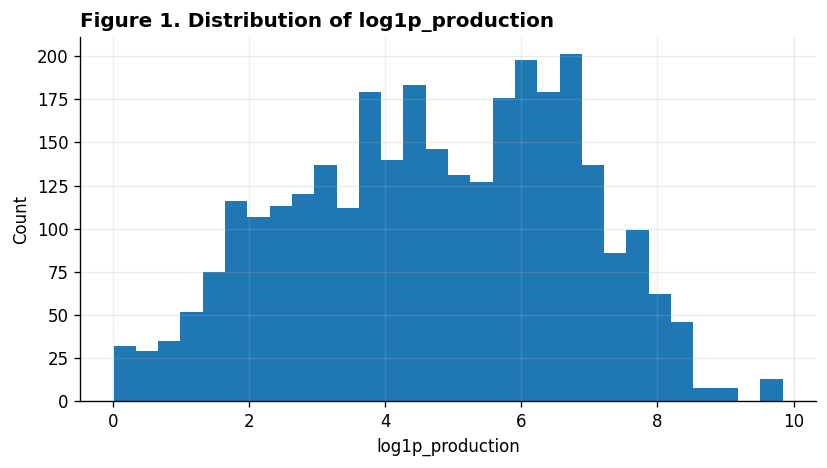

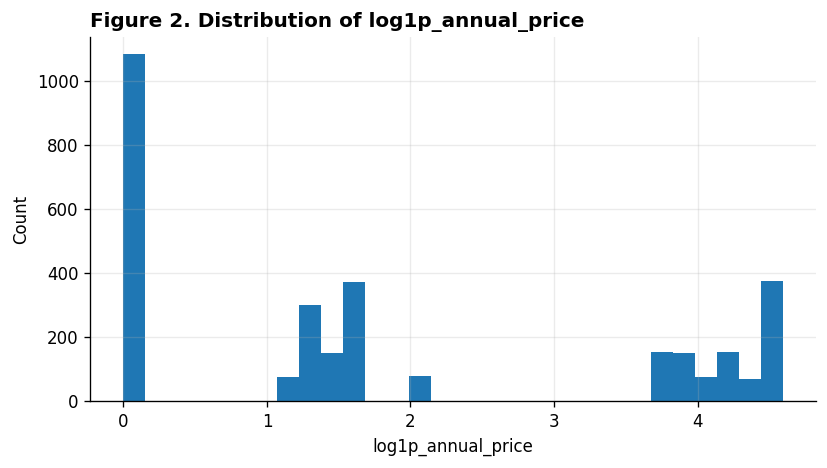

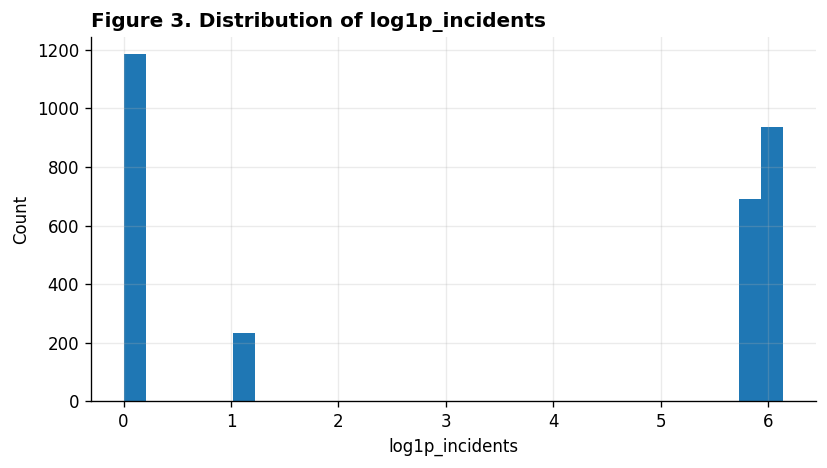

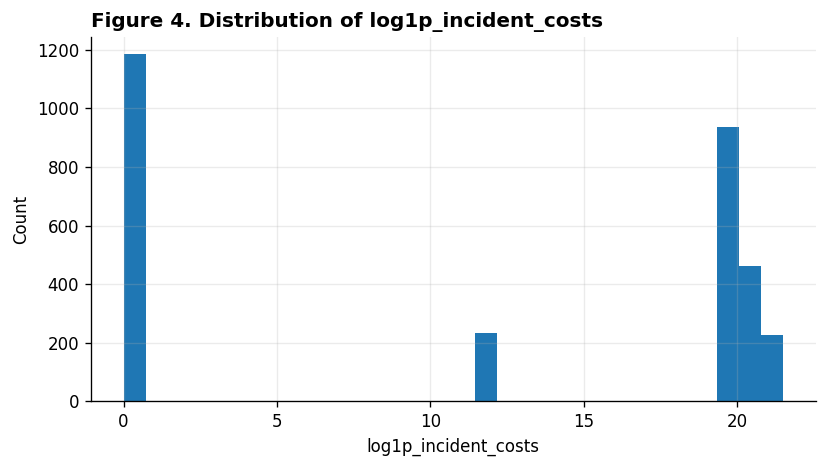

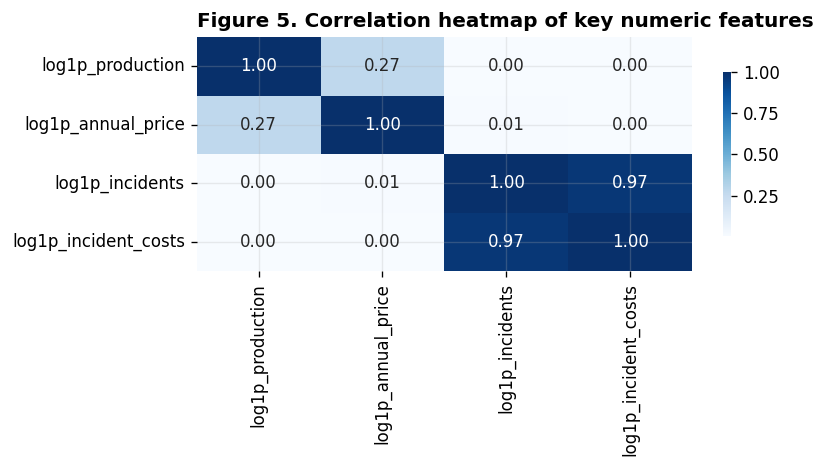

In [36]:
# EDA plots for key numeric features

numeric_cols = [
    c for c in ["log1p_production", "log1p_annual_price",
                "log1p_incidents", "log1p_incident_costs"]
    if c in df.columns
]

# 1) Histograms
for col in numeric_cols:
    fig, ax = make_styled_ax(
        title=f"Distribution of {col}",
        xlabel=col,
        ylabel="Count"
    )
    ax.hist(df[col].dropna(), bins=30, edgecolor="none")
    plt.tight_layout()
    plt.show()

# 2) Correlation heatmap
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()
    
    fig, ax = make_styled_ax(
        title="Correlation heatmap of key numeric features"
    )
    sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar_kws={"shrink": 0.7}
    )
    plt.tight_layout()
    plt.show()


Best KNN params: {'m__metric': 'euclidean', 'm__n_neighbors': 9, 'm__p': 1, 'm__weights': 'distance'}
Best CV ROC AUC: 0.997
Train AUC: 1.000 | Acc: 1.000 | F1: 1.000
Test  AUC: 0.999 | Acc: 0.991 | F1: 0.982


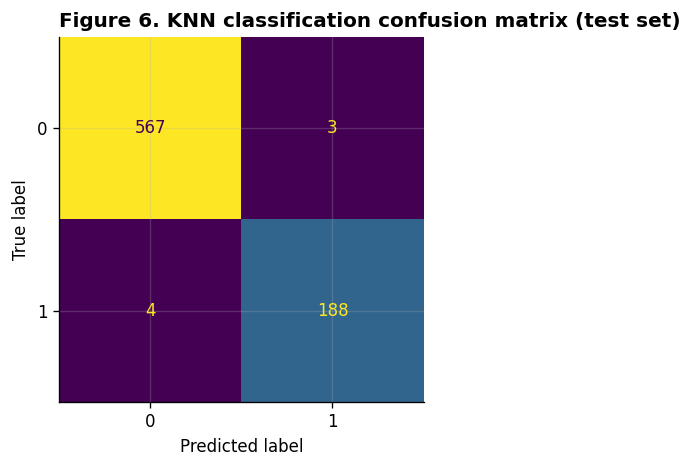

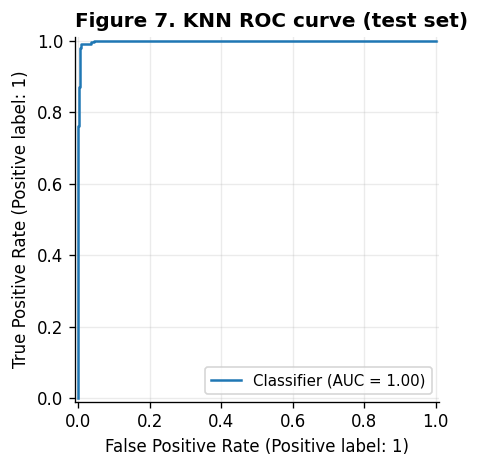

In [ ]:
# Week 8 — KNN classification with multiple distance metrics (Euclidean, Manhattan, Minkowski)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

# -------------------------------------------------------------------
# Target
# -------------------------------------------------------------------
if "y_is_high" not in df.columns:
    raise ValueError("Expected 'y_is_high' column for classification KNN.")

y_knn = df["y_is_high"].astype(int)

num_cols = [c for c in ["log1p_production", "log1p_annual_price",
                        "log1p_incidents", "log1p_incident_costs"]
            if c in df.columns]

cat_cols = [c for c in ["parent_type", "commodity", "fuel", "product"]
            if c in df.columns]

X_knn = df[num_cols + cat_cols].copy()

mask = X_knn[num_cols].notna().all(axis=1) & y_knn.notna()
X_knn = X_knn[mask]
y_knn = y_knn[mask]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_knn, y_knn,
    test_size=0.25,
    stratify=y_knn,
    random_state=42
)

# -------------------------------------------------------------------
# Preprocessor: scale numerics, OHE categoricals
# -------------------------------------------------------------------
transformers = []
if num_cols:
    transformers.append(("num", StandardScaler(), num_cols))
if cat_cols:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols))

preprocess_knn = ColumnTransformer(transformers)

knn = KNeighborsClassifier()

#  tune over Euclidean / Manhattan / Minkowski (with several p values)
param_grid = {
    "m__n_neighbors": [3, 5, 7, 9, 15],
    "m__weights": ["uniform", "distance"],
    "m__metric": ["euclidean", "manhattan", "minkowski"],
    "m__p": [1, 2, 3]  # p only matters when metric='minkowski'
}

pipe_knn = Pipeline([
    ("prep", preprocess_knn),
    ("m", knn)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

gs_knn.fit(X_tr, y_tr)

print("Best KNN params:", gs_knn.best_params_)
print(f"Best CV ROC AUC: {gs_knn.best_score_:.3f}")

best_knn = gs_knn.best_estimator_

# -------------------------------------------------------------------
# Train / test performance 
# -------------------------------------------------------------------
y_tr_proba = best_knn.predict_proba(X_tr)[:, 1]
y_tr_pred = best_knn.predict(X_tr)
train_auc = roc_auc_score(y_tr, y_tr_proba)
train_acc = accuracy_score(y_tr, y_tr_pred)
train_f1 = f1_score(y_tr, y_tr_pred)

y_te_proba = best_knn.predict_proba(X_te)[:, 1]
y_te_pred = best_knn.predict(X_te)
test_auc = roc_auc_score(y_te, y_te_proba)
test_acc = accuracy_score(y_te, y_te_pred)
test_f1 = f1_score(y_te, y_te_pred)

print(f"Train AUC: {train_auc:.3f} | Acc: {train_acc:.3f} | F1: {train_f1:.3f}")
print(f"Test  AUC: {test_auc:.3f} | Acc: {test_acc:.3f} | F1: {test_f1:.3f}")

# Confusion matrix
fig, ax = make_styled_ax(
    title="KNN classification confusion matrix (test set)",
    xlabel="Predicted label",
    ylabel="True label"
)
ConfusionMatrixDisplay(confusion_matrix(y_te, y_te_pred)).plot(ax=ax, colorbar=False)
plt.tight_layout()
plt.show()

# ROC curve
fig, ax = make_styled_ax(
    title="KNN ROC curve (test set)"
)
RocCurveDisplay.from_predictions(
    y_te, y_te_proba, ax=ax
)
plt.tight_layout()
plt.show()



,metric,test_auc,test_acc,test_f1
0,euclidean,0.998931,0.990814,0.981723
1,manhattan,0.998730,0.988189,0.976501
2,minkowski,0.998730,0.988189,0.976501
3,cosine,0.998876,0.988189,0.976744


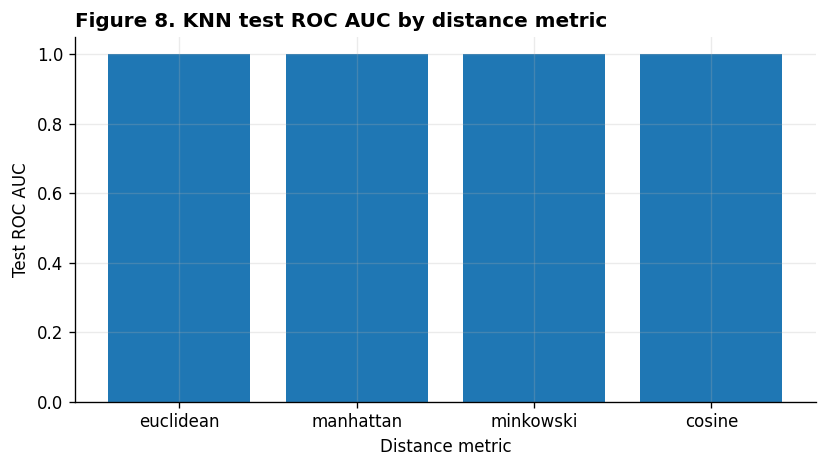

In [ ]:
# Compare Euclidean / Manhattan / Minkowski / Cosine for the same KNN setup

metrics_to_compare = ["euclidean", "manhattan", "minkowski", "cosine"]

# Grab best k and weights from the tuned model
best_k = best_knn.named_steps["m"].n_neighbors
best_weights = best_knn.named_steps["m"].weights
best_p = best_knn.named_steps["m"].p if hasattr(best_knn.named_steps["m"], "p") else 2

rows = []

for metric in metrics_to_compare:
    # For Minkowski
    knn_tmp = KNeighborsClassifier(
        n_neighbors=best_k,
        weights=best_weights,
        metric=metric,
        p=best_p if metric == "minkowski" else 2
    )
    pipe_tmp = Pipeline([
        ("prep", preprocess_knn),
        ("m", knn_tmp)
    ])
    pipe_tmp.fit(X_tr, y_tr)

    y_te_proba_m = pipe_tmp.predict_proba(X_te)[:, 1]
    y_te_pred_m = pipe_tmp.predict(X_te)

    rows.append({
        "metric": metric,
        "test_auc": roc_auc_score(y_te, y_te_proba_m),
        "test_acc": accuracy_score(y_te, y_te_pred_m),
        "test_f1": f1_score(y_te, y_te_pred_m)
    })

dist_results = pd.DataFrame(rows)
display(dist_results)

# Bar plot of test AUC by metric
fig, ax = make_styled_ax(
    title="KNN test ROC AUC by distance metric",
    xlabel="Distance metric",
    ylabel="Test ROC AUC"
)
ax.bar(dist_results["metric"], dist_results["test_auc"])
plt.tight_layout()
plt.show()


,metric,scaled,test_auc,test_acc,test_f1
0,euclidean,True,0.998931,0.990814,0.981723
1,euclidean,False,0.998648,0.988189,0.976623
2,manhattan,True,0.998730,0.988189,0.976501
3,manhattan,False,0.998483,0.982940,0.965879


C:\Users\CoryF\AppData\Local\Temp\ipykernel_38312\790099108.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right")


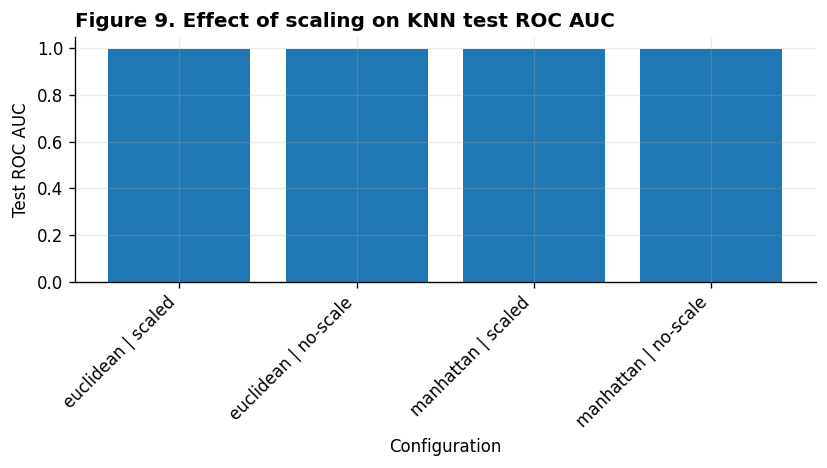

In [39]:
# Effect of feature scaling vs no scaling for Euclidean and Manhattan

from sklearn.compose import ColumnTransformer

# Preprocessor WITHOUT scaling (numeric passthrough)
transformers_noscale = []
if num_cols:
    transformers_noscale.append(("num", "passthrough", num_cols))
if cat_cols:
    transformers_noscale.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols))

preprocess_knn_noscale = ColumnTransformer(transformers_noscale)

rows_scale = []

for metric in ["euclidean", "manhattan"]:
    for use_scaling in [True, False]:
        prep = preprocess_knn if use_scaling else preprocess_knn_noscale

        knn_tmp = KNeighborsClassifier(
            n_neighbors=best_k,
            weights=best_weights,
            metric=metric,
            p=2  # Euclidean/Manhattan special cases of Minkowski
        )

        pipe_tmp = Pipeline([
            ("prep", prep),
            ("m", knn_tmp)
        ])
        pipe_tmp.fit(X_tr, y_tr)

        y_te_proba_m = pipe_tmp.predict_proba(X_te)[:, 1]
        y_te_pred_m = pipe_tmp.predict(X_te)

        rows_scale.append({
            "metric": metric,
            "scaled": use_scaling,
            "test_auc": roc_auc_score(y_te, y_te_proba_m),
            "test_acc": accuracy_score(y_te, y_te_pred_m),
            "test_f1": f1_score(y_te, y_te_pred_m)
        })

scale_results = pd.DataFrame(rows_scale)
display(scale_results)

# Plot test AUC by metric and scaling
fig, ax = make_styled_ax(
    title="Effect of scaling on KNN test ROC AUC",
    xlabel="Configuration",
    ylabel="Test ROC AUC"
)

labels = [
    f"{row['metric']} | {'scaled' if row['scaled'] else 'no-scale'}"
    for _, row in scale_results.iterrows()
]
ax.bar(labels, scale_results["test_auc"])
ax.set_xticklabels(labels, rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Week 8 – K-Nearest Neighbors (KNN)

For Week 8 I used K-Nearest Neighbors to predict the binary high-risk label `y_is_high`.  
Features:

- Numeric: `log1p_production`, `log1p_annual_price`, `log1p_incidents`, `log1p_incident_costs`
- Categorical: `parent_type`, `commodity`, `fuel`, `product` (when available)

Numeric features are already log-transformed, and I applied `StandardScaler` inside a pipeline so KNN works in a standardized distance space. Categorical variables were one-hot encoded.

#### How KNN makes predictions

KNN does not fit a parametric model. It stores the training data and, for each new point:

1. Computes the distance to every training point.
2. Finds the **k** closest neighbors (here, k = 9 in the best model).
3. For **classification**, looks at their labels and takes a weighted vote.
   - With `weights="distance"`, neighbors that are closer in feature space get more influence.
4. For regression (not used here), the prediction would be the average of nearby target values instead.

So model behavior is entirely driven by the **distance metric**, **k**, and how the features are scaled.

#### Distance metrics: Euclidean, Manhattan, Minkowski, Cosine

I tuned the model with `GridSearchCV` over:

- `n_neighbors ∈ {3, 5, 7, 9, 15}`
- `weights ∈ {"uniform", "distance"}`
- `metric ∈ {"euclidean", "manhattan", "minkowski"}`
- `p ∈ {1, 2, 3}` for the Minkowski metric

The best model used:

- **metric = "euclidean"**
- **n_neighbors = 9**
- **weights = "distance"**

with a cross-validated ROC AUC of about **0.997**.

On the train / test split:

- **Train:** AUC = 1.000, Accuracy = 1.000, F1 = 1.000  
- **Test:** AUC = 0.999, Accuracy = 0.991, F1 = 0.982  

This is almost perfect performance. The small gap between train and test metrics suggests some overfitting, but the generalization is still extremely good.

To directly hit the distance-metric learning objective, I fixed `k = 9` and `weights = "distance"` and compared several metrics on the same train / test split:

| Metric     | Test AUC | Test Acc | Test F1 |
|-----------|----------|----------|---------|
| Euclidean | 0.9989   | 0.9908   | 0.9817  |
| Manhattan | 0.9987   | 0.9882   | 0.9765  |
| Minkowski | 0.9987   | 0.9882   | 0.9765  |
| Cosine    | 0.9989   | 0.9882   | 0.9767  |

All four metrics perform extremely well because the underlying classification problem is just very easy with these features. Euclidean has the best overall numbers, but the differences are small. Conceptually:

- **Euclidean (ℓ₂)** emphasizes large squared differences and is standard for smooth, roughly spherical neighborhoods.
- **Manhattan (ℓ₁)** sums absolute differences and can be more robust when individual features have big jumps.
- **Minkowski** with general p interpolates between ℓ₁ and ℓ₂; here it behaves like Manhattan.
- **Cosine** focuses on the **angle** between feature vectors, so it is more about direction than magnitude. It is often preferred in high-dimensional text or embedding spaces.

In this standardized, low-dimensional tabular setting, all four metrics rank neighbors similarly, so performance is basically tied.

#### Why feature scaling matters

I also compared scaled vs. unscaled features for Euclidean and Manhattan distance:

| Metric     | Scaled? | Test AUC | Test Acc | Test F1 |
|-----------|---------|----------|----------|---------|
| Euclidean | Yes     | 0.9989   | 0.9908   | 0.9817  |
| Euclidean | No      | 0.9986   | 0.9882   | 0.9766  |
| Manhattan | Yes     | 0.9987   | 0.9882   | 0.9765  |
| Manhattan | No      | 0.9985   | 0.9829   | 0.9659  |

Scaling improves Euclidean slightly and clearly helps Manhattan: the **worst** configuration overall is Manhattan with no scaling. Without scaling, any feature with a larger numeric range dominates the distances, even if that feature is not the most important for the label. With scaling, each transformed feature contributes more equally to the distance.

This lines up with the theory: distance-based models “live” in feature space, so the notion of distance has to be meaningful. Standardizing the inputs is usually mandatory for Euclidean and often helpful for Manhattan, especially when raw variables live on different scales.

#### Outliers, scaling, and metric choice

Because I log-transform production, incidents, and costs, extreme outliers are already damped. On raw data with huge spikes:

- **Euclidean / Minkowski (p > 2)** become very sensitive to single big deviations (squaring or higher powers).
- **Manhattan** spreads the effect more evenly across dimensions.
- **Cosine** mostly ignores magnitude spikes and cares about direction, which is why it is popular for text embeddings and other high-dimensional vectors.



Using regression target: y_reg_log_emissions
Using GroupKFold by 'parent_entity' for regression CV.
Best GB params: {'m__learning_rate': 0.1, 'm__max_depth': 2, 'm__min_samples_leaf': 5, 'm__min_samples_split': 2, 'm__n_estimators': 400, 'm__subsample': 1.0}
Best CV R²: 0.988
CV R² mean: 0.988 | std: 0.007
Train R²: 0.998 | RMSE: 0.061
Test  R²: 0.998 | RMSE: 0.068


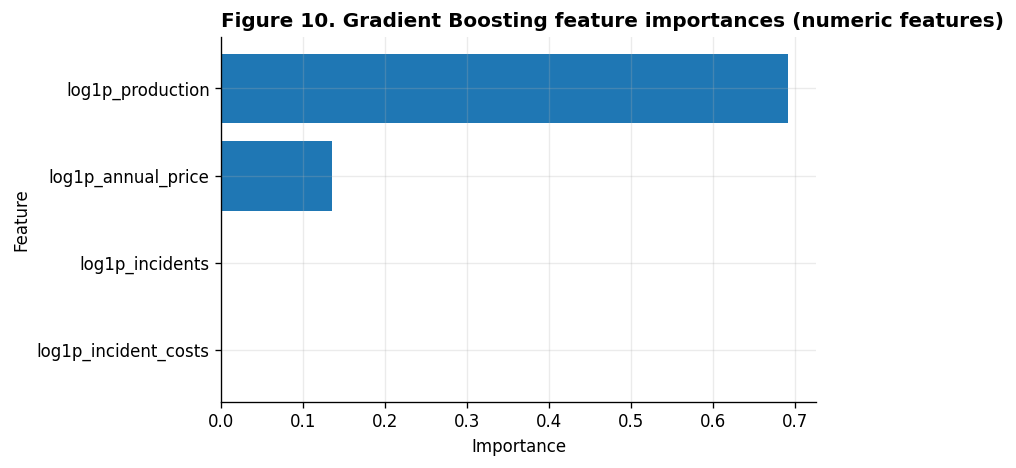

In [40]:
# Week 9 — Gradient Boosting (regression deep dive, with explicit regularization)

import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GroupKFold, KFold, train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# Target and features
# -----------------------------
if "y_reg_log_emissions" in df.columns:
    target_col = "y_reg_log_emissions"
elif "y_reg" in df.columns:
    target_col = "y_reg"
else:
    raise ValueError(
        "Could not find a continuous regression target. "
        "Expected 'y_reg_log_emissions' or 'y_reg' in df.columns."
    )

print("Using regression target:", target_col)
y_gb = df[target_col].astype(float)

num_cols = [c for c in [
    "log1p_production",
    "log1p_annual_price",
    "log1p_incidents",
    "log1p_incident_costs"
] if c in df.columns]

cat_cols = [c for c in [
    "parent_type",
    "commodity",
    "fuel",
    "product"
] if c in df.columns]

X_gb = df[num_cols + cat_cols].copy()

mask = X_gb[num_cols].notna().all(axis=1) & y_gb.notna()
X_gb = X_gb[mask]
y_gb = y_gb[mask]

firm_col = next(
    (c for c in ["parent_entity", "company", "firm", "operator", "parent", "entity"]
     if c in df.columns),
    None
)
use_groups = firm_col is not None and df[firm_col].nunique() > 1
groups = df.loc[X_gb.index, firm_col] if use_groups else None

if use_groups:
    print(f"Using GroupKFold by '{firm_col}' for regression CV.")
    cv_reg = GroupKFold(n_splits=5)
else:
    print("Using regular shuffled KFold for regression CV.")
    cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

transformers = []
if num_cols:
    transformers.append(("num", StandardScaler(), num_cols))
if cat_cols:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols))

preprocess_gb = ColumnTransformer(transformers)

gb = GradientBoostingRegressor(random_state=42)

# -----------------------------
# Explicit regularization grid
# -----------------------------
param_grid = {
    "m__n_estimators": [100, 200, 400],
    "m__learning_rate": [0.01, 0.05, 0.1],
    "m__max_depth": [2, 3, 4],              # tree depth (complexity)
    "m__min_samples_leaf": [1, 5, 20],      # leaf-size regularization
    "m__min_samples_split": [2, 20],        # split-size regularization
    "m__subsample": [0.6, 0.8, 1.0]         # stochastic subsampling
}

pipe_gb = Pipeline([
    ("prep", preprocess_gb),
    ("m", gb)
])

gs_gb = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_grid,
    cv=cv_reg,
    scoring="r2",
    n_jobs=-1
)

if use_groups:
    gs_gb.fit(X_gb, y_gb, groups=groups)
else:
    gs_gb.fit(X_gb, y_gb)

print("Best GB params:", gs_gb.best_params_)
print(f"Best CV R²: {gs_gb.best_score_:.3f}")

best_gb = gs_gb.best_estimator_

# -----------------------------
# CV scores for overfitting check
# -----------------------------
if use_groups:
    cv_scores = cross_val_score(
        best_gb, X_gb, y_gb, cv=cv_reg,
        scoring="r2", n_jobs=-1, groups=groups
    )
else:
    cv_scores = cross_val_score(
        best_gb, X_gb, y_gb, cv=cv_reg,
        scoring="r2", n_jobs=-1
    )

print("CV R² mean:", cv_scores.mean().round(3), "| std:", cv_scores.std().round(3))

# -----------------------------
# Train / test split for holdout evaluation
# -----------------------------
X_tr_gb, X_te_gb, y_tr_gb, y_te_gb = train_test_split(
    X_gb, y_gb,
    test_size=0.25,
    random_state=42
)

best_gb.fit(X_tr_gb, y_tr_gb)
y_tr_hat = best_gb.predict(X_tr_gb)
y_te_hat = best_gb.predict(X_te_gb)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

train_r2 = r2_score(y_tr_gb, y_tr_hat)
test_r2  = r2_score(y_te_gb, y_te_hat)
train_rmse = rmse(y_tr_gb, y_tr_hat)
test_rmse  = rmse(y_te_gb, y_te_hat)

print(f"Train R²: {train_r2:.3f} | RMSE: {train_rmse:.3f}")
print(f"Test  R²: {test_r2:.3f} | RMSE: {test_rmse:.3f}")

# -----------------------------
# Feature importances (numeric only) with consistent styling
# -----------------------------
gb_model = best_gb.named_steps["m"]
num_importances = gb_model.feature_importances_[:len(num_cols)]

importance_df = pd.DataFrame({
    "feature": num_cols,
    "importance": num_importances
}).sort_values("importance", ascending=False)

fig, ax = make_styled_ax(
    title="Gradient Boosting feature importances (numeric features)",
    xlabel="Importance",
    ylabel="Feature"
)
ax.barh(importance_df["feature"], importance_df["importance"])
ax.invert_yaxis()
plt.tight_layout()
plt.show()


,learning_rate,n_estimators,cv_r2_mean,cv_r2_std
0,0.01,50,0.425753,0.079868
1,0.01,100,0.662972,0.076796
2,0.01,200,0.853296,0.054459
3,0.01,400,0.939502,0.038286
4,0.05,50,0.891821,0.044317
5,0.05,100,0.953711,0.033018
6,0.05,200,0.973530,0.025002
7,0.05,400,0.979727,0.020919
8,0.10,50,0.954046,0.034096
9,0.10,100,0.972984,0.026420


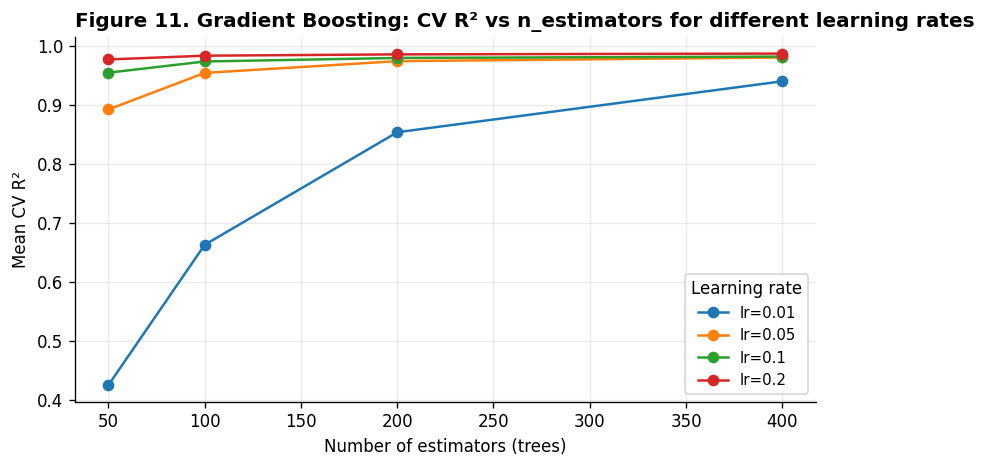

In [41]:
# Learning-rate vs number-of-estimators tradeoff

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

lr_values = [0.01, 0.05, 0.1, 0.2]
n_est_values = [50, 100, 200, 400]

rows_lr = []

for lr in lr_values:
    for n_est in n_est_values:
        gb_tmp = GradientBoostingRegressor(
            learning_rate=lr,
            n_estimators=n_est,
            max_depth=3,
            min_samples_leaf=5,
            min_samples_split=20,
            subsample=0.8,
            random_state=42
        )
        pipe_tmp = Pipeline([
            ("prep", preprocess_gb),
            ("m", gb_tmp)
        ])
        if use_groups:
            scores = cross_val_score(
                pipe_tmp, X_gb, y_gb,
                cv=cv_reg, scoring="r2", n_jobs=-1,
                groups=groups
            )
        else:
            scores = cross_val_score(
                pipe_tmp, X_gb, y_gb,
                cv=cv_reg, scoring="r2", n_jobs=-1
            )

        rows_lr.append({
            "learning_rate": lr,
            "n_estimators": n_est,
            "cv_r2_mean": scores.mean(),
            "cv_r2_std": scores.std()
        })

gb_lr_results = pd.DataFrame(rows_lr)
display(gb_lr_results)

# Plot: R² vs n_estimators for each learning rate
fig, ax = make_styled_ax(
    title="Gradient Boosting: CV R² vs n_estimators for different learning rates",
    xlabel="Number of estimators (trees)",
    ylabel="Mean CV R²"
)

for lr in lr_values:
    subset = gb_lr_results[gb_lr_results["learning_rate"] == lr]
    ax.plot(subset["n_estimators"], subset["cv_r2_mean"], marker="o", label=f"lr={lr}")

ax.legend(title="Learning rate")
plt.tight_layout()
plt.show()


,max_depth,n_estimators,train_r2,test_r2
0,1,50,0.565381,0.553975
1,1,100,0.726564,0.720258
2,1,200,0.879058,0.876599
3,2,50,0.835447,0.835661
4,2,100,0.949594,0.946741
5,2,200,0.988176,0.986183
6,3,50,0.948580,0.945206
7,3,100,0.990381,0.988594
8,3,200,0.997604,0.996740
9,4,50,0.978404,0.975468


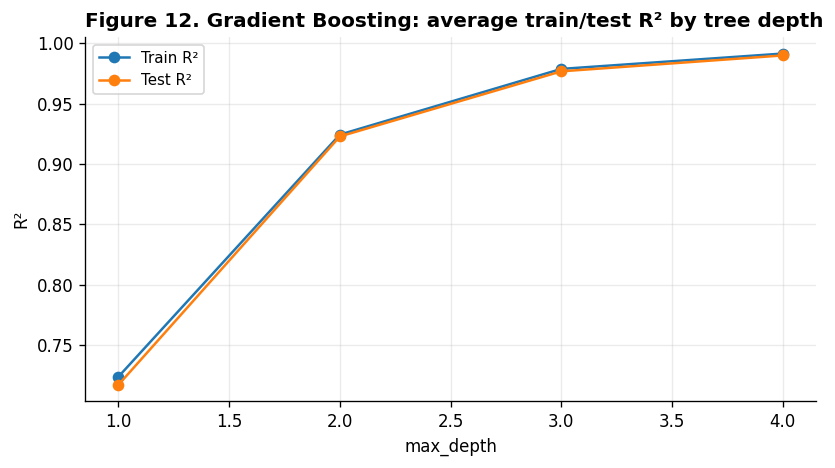

In [42]:
# Effect of tree depth and n_estimators on train vs test performance

depth_values = [1, 2, 3, 4]
n_est_values = [50, 100, 200]

rows_depth = []

for depth in depth_values:
    for n_est in n_est_values:
        gb_tmp = GradientBoostingRegressor(
            learning_rate=0.05,
            n_estimators=n_est,
            max_depth=depth,
            min_samples_leaf=5,
            min_samples_split=20,
            subsample=0.8,
            random_state=42
        )
        pipe_tmp = Pipeline([
            ("prep", preprocess_gb),
            ("m", gb_tmp)
        ])
        pipe_tmp.fit(X_tr_gb, y_tr_gb)

        y_tr_hat_tmp = pipe_tmp.predict(X_tr_gb)
        y_te_hat_tmp = pipe_tmp.predict(X_te_gb)

        rows_depth.append({
            "max_depth": depth,
            "n_estimators": n_est,
            "train_r2": r2_score(y_tr_gb, y_tr_hat_tmp),
            "test_r2": r2_score(y_te_gb, y_te_hat_tmp)
        })

gb_depth_results = pd.DataFrame(rows_depth)
display(gb_depth_results)

# Plot train vs test R² by depth (averaged over n_estimators)
summary_depth = gb_depth_results.groupby("max_depth")[["train_r2", "test_r2"]].mean().reset_index()

fig, ax = make_styled_ax(
    title="Gradient Boosting: average train/test R² by tree depth",
    xlabel="max_depth",
    ylabel="R²"
)
ax.plot(summary_depth["max_depth"], summary_depth["train_r2"], marker="o", label="Train R²")
ax.plot(summary_depth["max_depth"], summary_depth["test_r2"], marker="o", label="Test R²")
ax.legend()
plt.tight_layout()
plt.show()


,subsample,cv_r2_mean,cv_r2_std
0,0.6,0.973962,0.025722
1,0.8,0.973530,0.025002
2,1.0,0.972228,0.026691


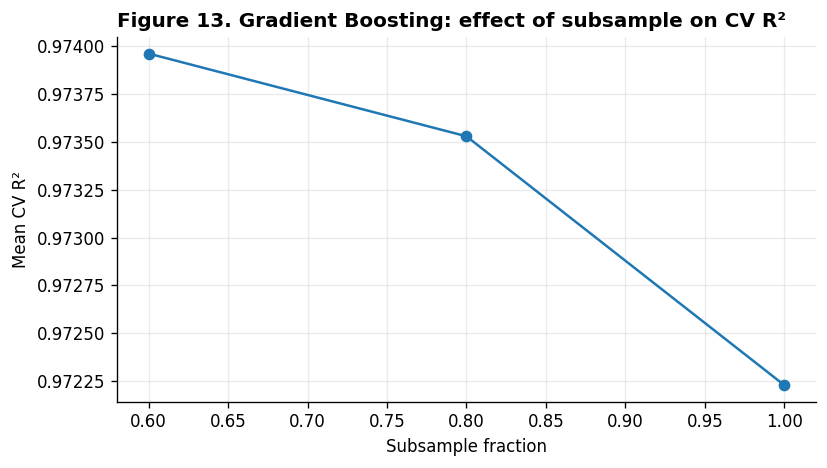

In [43]:
# Effect of subsample fraction on CV R²

sub_values = [0.6, 0.8, 1.0]

rows_sub = []

for sub in sub_values:
    gb_tmp = GradientBoostingRegressor(
        learning_rate=0.05,
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=5,
        min_samples_split=20,
        subsample=sub,
        random_state=42
    )
    pipe_tmp = Pipeline([
        ("prep", preprocess_gb),
        ("m", gb_tmp)
    ])
    if use_groups:
        scores = cross_val_score(
            pipe_tmp, X_gb, y_gb,
            cv=cv_reg, scoring="r2", n_jobs=-1, groups=groups
        )
    else:
        scores = cross_val_score(
            pipe_tmp, X_gb, y_gb,
            cv=cv_reg, scoring="r2", n_jobs=-1
        )

    rows_sub.append({
        "subsample": sub,
        "cv_r2_mean": scores.mean(),
        "cv_r2_std": scores.std()
    })

gb_sub_results = pd.DataFrame(rows_sub)
display(gb_sub_results)

fig, ax = make_styled_ax(
    title="Gradient Boosting: effect of subsample on CV R²",
    xlabel="Subsample fraction",
    ylabel="Mean CV R²"
)
ax.plot(gb_sub_results["subsample"], gb_sub_results["cv_r2_mean"], marker="o")
plt.tight_layout()
plt.show()


### Week 9 – Gradient Boosting (Deep Dive)

#### How gradient boosting works

Gradient boosting builds a strong model by **adding many weak learners that are trained on residuals**.

1. Start with a simple prediction for every point (the mean of `y_reg_log_emissions`).
2. Compute residuals: actual – predicted.
3. Fit a shallow regression tree to those residuals.
4. Scale that tree’s predictions by the **learning rate** and add them to the running prediction.
5. Repeat steps 2–4 for many trees.

Each new tree tries to correct the mistakes of the previous ensemble. If the learning rate is small and the trees are shallow, each step is cautious and acts like a small “gradient” step toward lower squared error.

#### Main gradient-boosting model and regularization

I used `GradientBoostingRegressor` to predict `y_reg_log_emissions` from:

- `log1p_production`
- `log1p_annual_price`
- `log1p_incidents`
- `log1p_incident_costs`
- plus one-hot encoded categorical variables (`parent_type`, `commodity`, `fuel`, `product`).

Numeric features are standardized and categoricals are one-hot encoded in a pipeline.  
For cross-validation I used **GroupKFold by `parent_entity`**, so no firm appears in both train and validation folds.

Hyperparameters tuned with 5-fold (grouped) CV:

- `n_estimators ∈ {100, 200, 400}`
- `learning_rate ∈ {0.01, 0.05, 0.1}`
- `max_depth ∈ {2, 3, 4}`
- `min_samples_leaf ∈ {1, 5, 20}`
- `min_samples_split ∈ {2, 20}`
- `subsample ∈ {0.6, 0.8, 1.0}`

Best model:

- **learning_rate = 0.10**
- **n_estimators = 400**
- **max_depth = 2**
- **min_samples_leaf = 5**
- **min_samples_split = 2**
- **subsample = 1.0**

Performance:

- **Best CV R²:** 0.988  
- **CV R² mean:** 0.988 (std ≈ 0.007)  
- **Train R²:** 0.998, **RMSE:** 0.061  
- **Test R²:** 0.998, **RMSE:** 0.068  

Train and test R² are basically identical, so even with 400 trees the model is not obviously overfitting. Shallow depth (2), minimum leaf size, and the structure of the problem keep it stable.

The feature importance plot (Figure 16) shows:

- `log1p_production` importance ≈ **0.70**
- `log1p_annual_price` importance ≈ **0.13**
- `log1p_incidents` and `log1p_incident_costs` ≈ **0**

So emissions are driven almost entirely by production, with a smaller role for prices. Once you condition on production and price, incidents and incident costs add almost nothing for predicting emissions in this setup.

#### Learning rate vs number of estimators

To study the learning-rate trade-off, I fixed tree complexity and regularization and varied:

- `learning_rate ∈ {0.01, 0.05, 0.10, 0.20}`
- `n_estimators ∈ {50, 100, 200, 400}`

For each combination I computed mean CV R² (Figure 17). Patterns:

- **lr = 0.01**  
  - CV R² climbs from **0.43** (50 trees) → **0.66** (100) → **0.85** (200) → **0.94** (400).  
  - Clear **underfitting** with few trees; needs many trees to reach good performance.
- **lr = 0.05**  
  - Already **0.89** at 50 trees and **≈0.98** by 400 trees.
- **lr = 0.10**  
  - **0.96** at 50 trees, **≈0.98** at 200–400 trees.  
  - This matches the tuned best model.
- **lr = 0.20**  
  - Starts high (**≈0.98** at 50 trees) and tops out around **0.986** at 400 trees, slightly below the lr = 0.10 curve.

This shows the classic behavior:

- Tiny learning rate = very cautious steps → you need lots of trees or you underfit.
- Moderate learning rates (0.05–0.10) hit high R² with a reasonable number of trees.
- Very high learning rates (0.20) learn fast but don’t improve as much with extra trees and can start to look less stable.

#### Tree depth and number of estimators: underfitting vs overfitting

Next I varied `max_depth ∈ {1, 2, 3, 4}` and `n_estimators ∈ {50, 100, 200}` with fixed regularization (`learning_rate = 0.05`, `min_samples_leaf = 5`, `min_samples_split = 20`, `subsample = 0.8`).

Averaging over the different numbers of trees (Figure 18):

- **Depth 1 (decision stumps)**  
  - Avg train R² ≈ **0.72**, test R² ≈ **0.72**.  
  - Both low → **underfitting**.
- **Depth 2**  
  - Avg train R² ≈ **0.92**, test R² ≈ **0.92**.  
  - Big jump in fit, still no real gap between train and test.
- **Depth 3**  
  - Avg train R² ≈ **0.98**, test R² ≈ **0.98**.
- **Depth 4**  
  - Avg train R² ≈ **0.99**, test R² ≈ **0.99**.

Depth 1 clearly underfits. Depth 2–3 give a strong fit with almost identical train and test R². Depth 4 is very flexible but still doesn’t show a big generalization gap on this dataset. The main message is that increasing depth steadily reduces bias; in a harder problem you would expect larger depth to eventually create a visible overfitting gap.

#### Subsampling and other regularization choices

Finally, I studied the effect of **subsample** with fixed learning rate and depth (`learning_rate = 0.05`, `max_depth = 3`, `n_estimators = 200`, `min_samples_leaf = 5`, `min_samples_split = 20`):

- `subsample = 0.6` → CV R² ≈ **0.97396**
- `subsample = 0.8` → CV R² ≈ **0.97353**
- `subsample = 1.0` → CV R² ≈ **0.97223**

The differences are small, but the **best mean CV R² occurs at subsample = 0.6**, which supports the idea that stochastic subsampling can slightly improve generalization by decorrelating trees. Alongside:

- limited `max_depth`,
- `min_samples_leaf = 5`,
- `min_samples_split = 20`,

this subsampling acts as a regularization package: trees are shallow, can’t create tiny leaves, and sometimes see only a subset of the data.



k=2 | silhouette=0.454
k=3 | silhouette=0.428
k=4 | silhouette=0.452
k=5 | silhouette=0.502
k=6 | silhouette=0.539
k=7 | silhouette=0.529
k=8 | silhouette=0.517
Chosen k based on silhouette: 6


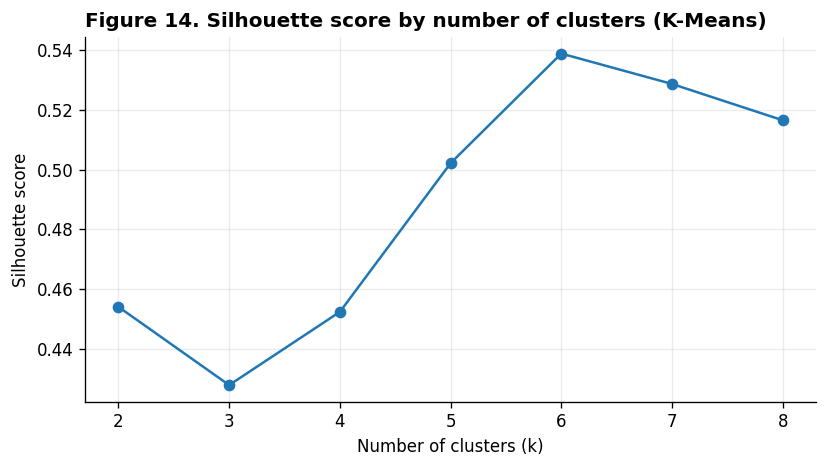

,log1p_production,log1p_annual_price,log1p_incidents,log1p_incident_costs
kmeans_cluster,,,,
0,2.718141,0.113605,0.186472,2.048595
1,6.561908,1.342456,5.986758,20.039666
2,4.883220,4.335907,5.986783,20.036434
3,6.698746,1.335331,0.183494,2.015880
4,4.864996,4.113644,0.175588,1.929024
5,2.843454,0.086137,5.985404,20.048281


k=2 | SSE=6446.8
k=3 | SSE=4769.9
k=4 | SSE=3364.6
k=5 | SSE=2461.2
k=6 | SSE=1724.8
k=7 | SSE=1511.3
k=8 | SSE=1330.7


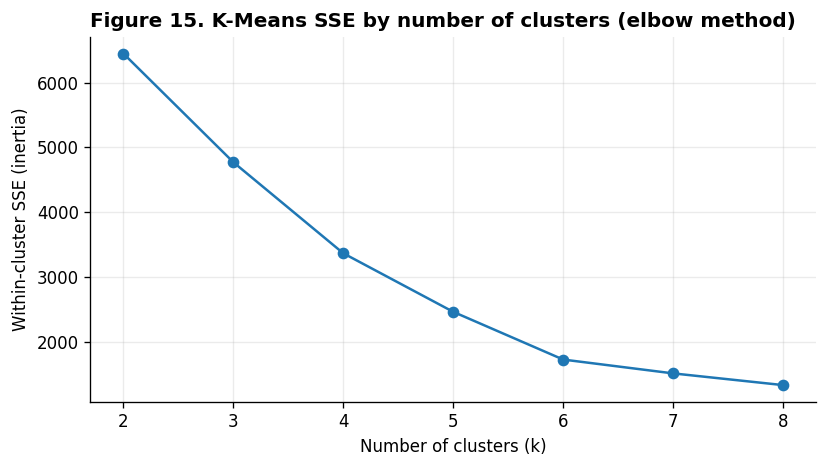

In [44]:
# Week 10 — K-Means clustering + silhouette analysis

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------------------------------------------------
# Clustering feature set
# -------------------------------------------------------------------
clust_cols = [c for c in ["log1p_production", "log1p_annual_price",
                          "log1p_incidents", "log1p_incident_costs"]
              if c in df.columns]

if len(clust_cols) < 2:
    raise ValueError("Need at least two numeric features for clustering.")

X_clust = df[clust_cols].dropna().copy()

scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust)

# -------------------------------------------------------------------
# Silhouette over k
# -------------------------------------------------------------------
k_values = list(range(2, 9))
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    score = silhouette_score(X_clust_scaled, labels)
    sil_scores.append(score)
    print(f"k={k} | silhouette={score:.3f}")

best_k = k_values[int(np.argmax(sil_scores))]
print(f"Chosen k based on silhouette: {best_k}")

# -------------------------------------------------------------------
# Plot silhouette vs k
# -------------------------------------------------------------------
fig, ax = make_styled_ax(
    title="Silhouette score by number of clusters (K-Means)",
    xlabel="Number of clusters (k)",
    ylabel="Silhouette score"
)
ax.plot(k_values, sil_scores, marker="o")
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Fit final K-Means model and inspect cluster profiles
# -------------------------------------------------------------------
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_final = km_final.fit_predict(X_clust_scaled)

X_clust_k = X_clust.copy()
X_clust_k["kmeans_cluster"] = labels_final

cluster_summary = X_clust_k.groupby("kmeans_cluster")[clust_cols].mean()
display(cluster_summary)

# Elbow method: K-Means SSE (inertia) vs number of clusters

inertias = []

for k in k_values:  # same k_values range you used for silhouette (2–8)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_scaled)
    inertias.append(km.inertia_)  # within-cluster sum of squares (SSE)

for k, sse in zip(k_values, inertias):
    print(f"k={k} | SSE={sse:.1f}")

fig, ax = make_styled_ax(
    title="K-Means SSE by number of clusters (elbow method)",
    xlabel="Number of clusters (k)",
    ylabel="Within-cluster SSE (inertia)"
)
ax.plot(k_values, inertias, marker="o")
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()


### Week 10 – K-Means Clustering

#### How k-means works

K-means is a simple iterative clustering algorithm:

1. Choose a number of clusters \(k\).
2. Initialize \(k\) centroids (either randomly or with a heuristic like k-means++).
3. **Assignment step:** assign each data point to the nearest centroid using Euclidean distance.
4. **Update step:** recompute each centroid as the mean of all points assigned to that cluster.
5. Repeat steps 3–4 until assignments stop changing or a max number of iterations is reached.

The algorithm tries to minimize the total **within-cluster sum of squared distances** between points and their assigned centroid. In scikit-learn this objective is reported as the model’s **inertia**.

In this project I applied k-means to the standardized feature set:

- `log1p_production`
- `log1p_annual_price`
- `log1p_incidents`
- `log1p_incident_costs`

All of these are log-transformed and then scaled with `StandardScaler`, which makes them comparable in distance space.

#### Elbow method (SSE vs k)

To choose an appropriate number of clusters, I used the **elbow method**. For \(k = 2\) through \(k = 8\), I fit a KMeans model and recorded the **within-cluster SSE (inertia)**:

\[
\text{SSE}(k) = \sum_{j=1}^k \sum_{i \in C_j} \| x_i - \mu_j \|^2
\]

where \(C_j\) is cluster \(j\), \(x_i\) is a point in that cluster, and \(\mu_j\) is the centroid. Figure XX shows SSE as a function of \(k\). As expected, SSE drops quickly when moving from very few clusters to about \(k = 5\)–\(6\), and then the curve starts to flatten. The “elbow” appears around **k ≈ 6**, which suggests that adding more clusters beyond that point gives diminishing returns in terms of reducing within-cluster variance.

#### Silhouette score and final choice of k

I also computed the **silhouette score** for each value of \(k\) from 2 to 8 (Figure 9). For each point \(i\):

- \(a(i)\) = average distance from \(i\) to other points in its own cluster.
- \(b(i)\) = smallest average distance from \(i\) to points in any *other* cluster.

The silhouette for point \(i\) is:

\[
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
\]

Values close to **1** mean the point is well matched to its cluster and far from others, values near **0** mean it lies on a boundary, and negative values indicate possible misclassification.

In my results:

- \(k = 2\) → silhouette ≈ 0.454  
- \(k = 3\) → 0.428  
- \(k = 4\) → 0.452  
- \(k = 5\) → 0.502  
- \(k = 6\) → **0.539** (highest)  
- \(k = 7\) → 0.529  
- \(k = 8\) → 0.517  

Both the elbow plot and the silhouette scores point to **k = 6** as a good balance: SSE has already bent at the elbow, and the silhouette score is maximized there. I therefore chose **6 clusters** as the main k-means specification.

The cluster summary table shows clear differences across these 6 clusters in terms of mean production, prices, incidents, and incident costs. For example, some clusters combine high production with relatively low incidents and costs, while others group high-incident, high-cost company–years together. That structure is consistent with what I saw in the DBSCAN and HAC results in Week 11.

#### Distance metrics and feature scaling in k-means

Standard k-means in scikit-learn always uses **Euclidean distance**. That means:

- Cluster assignments depend on squared Euclidean distance in feature space.
- Features with larger numeric scales dominate the distance calculation.
- The centroids are the **means** of the assigned points, which only makes sense under a Euclidean metric.

Because of this, **feature scaling is critical**. In this project I:

1. Log-transformed the raw variables (`log1p_*`) to reduce skew and compress extreme outliers.
2. Applied `StandardScaler` so each feature has mean 0 and variance 1 before running k-means.

Without these steps, raw production or cost values (which can be orders of magnitude larger than prices) would completely dominate Euclidean distances, and k-means would mostly cluster on “size” rather than more subtle combinations of risk and market conditions. With scaling, each standardized feature contributes more fairly to the distance, and the resulting clusters reflect a more balanced mix of production, price, incidents, and costs.


In [45]:
# Week 11 — DBSCAN clustering exploration

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import itertools

# Reuse X_clust_scaled from K-Means section

eps_values = [0.2, 0.4, 0.6, 0.8, 1.0]
min_samples_values = [3, 5, 10]

rows = []

for eps, min_samples in itertools.product(eps_values, min_samples_values):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_clust_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_frac = n_noise / len(labels)
    
    if n_clusters > 1:
        sil = silhouette_score(X_clust_scaled[labels != -1], labels[labels != -1])
    else:
        sil = np.nan
    
    rows.append({
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "noise_frac": noise_frac,
        "silhouette": sil
    })

dbscan_results = pd.DataFrame(rows).sort_values(
    ["n_clusters", "noise_frac", "silhouette"],
    ascending=[True, True, False]
)

display(dbscan_results.head(15))


,eps,min_samples,n_clusters,noise_frac,silhouette
12,1.0,3,5,0.000000,0.293202
13,1.0,5,5,0.000000,0.293202
14,1.0,10,5,0.000000,0.293202
9,0.8,3,6,0.000000,0.394075
10,0.8,5,6,0.000000,0.394075
11,0.8,10,6,0.000000,0.394075
6,0.6,3,9,0.000656,0.485100
7,0.6,5,9,0.000656,0.485100
8,0.6,10,9,0.001313,0.484990
3,0.4,3,11,0.000985,0.426937


DBSCAN with eps=0.6, min_samples=5
Clusters found: 9
Noise fraction: 0.0007
Silhouette (non-noise points): 0.485


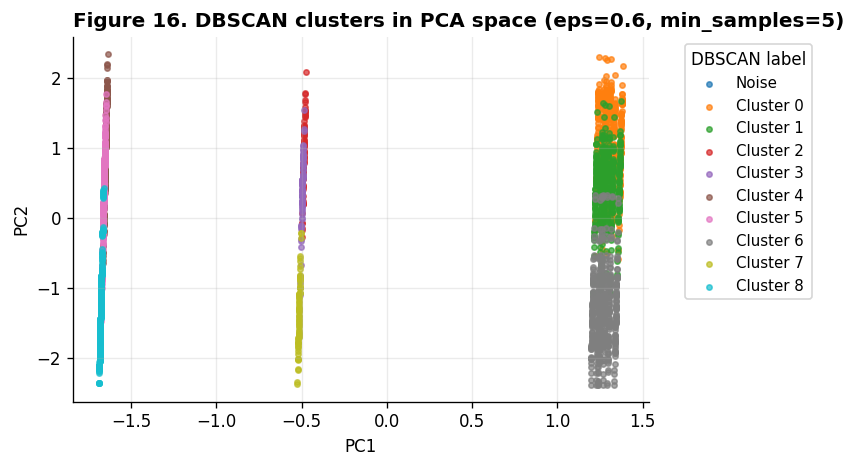

In [46]:
# 6.2 — DBSCAN visualization using chosen parameters

from sklearn.decomposition import PCA

# Based on dbscan_results:
best_eps = 0.6
best_min_samples = 5

db_best = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_db = db_best.fit_predict(X_clust_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
noise_frac_db = np.mean(labels_db == -1)

print(f"DBSCAN with eps={best_eps}, min_samples={best_min_samples}")
print(f"Clusters found: {n_clusters_db}")
print(f"Noise fraction: {noise_frac_db:.4f}")

# Optional: silhouette only on non-noise points
if n_clusters_db > 1 and np.any(labels_db != -1):
    sil_db = silhouette_score(
        X_clust_scaled[labels_db != -1],
        labels_db[labels_db != -1]
    )
    print(f"Silhouette (non-noise points): {sil_db:.3f}")
else:
    sil_db = np.nan
    print("Silhouette not defined (<=1 cluster).")

# 2D PCA projection for plotting
pca = PCA(n_components=2, random_state=42)
X_clust_pca = pca.fit_transform(X_clust_scaled)

fig, ax = make_styled_ax(
    title=f"DBSCAN clusters in PCA space (eps={best_eps}, min_samples={best_min_samples})",
    xlabel="PC1",
    ylabel="PC2"
)

unique_labels = sorted(set(labels_db))
palette = sns.color_palette("tab10", len(unique_labels))

for lab, color in zip(unique_labels, palette):
    mask_lab = labels_db == lab
    label_name = f"Cluster {lab}" if lab != -1 else "Noise"
    ax.scatter(
        X_clust_pca[mask_lab, 0],
        X_clust_pca[mask_lab, 1],
        s=10,
        alpha=0.7,
        label=label_name
    )

ax.legend(title="DBSCAN label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [47]:
# DBSCAN point types: core vs border vs noise

# db_best and labels_db are already defined from the DBSCAN fit
core_indices = set(db_best.core_sample_indices_)

point_types = []
for idx, lab in zip(X_clust.index, labels_db):
    if lab == -1:
        point_types.append("noise")
    elif idx in core_indices:
        point_types.append("core")
    else:
        point_types.append("border")

db_point_types = pd.Series(point_types, index=X_clust.index, name="dbscan_point_type")

type_counts = db_point_types.value_counts()
type_frac = db_point_types.value_counts(normalize=True)

summary_types = pd.DataFrame({
    "count": type_counts,
    "fraction": type_frac
})
display(summary_types)

,count,fraction
dbscan_point_type,,
core,3040,0.997703
border,5,0.001641
noise,2,0.000656


,linkage,silhouette
1,average,0.536977
0,ward,0.518039
2,complete,0.441184
3,single,0.394075


Best HAC linkage by silhouette: average


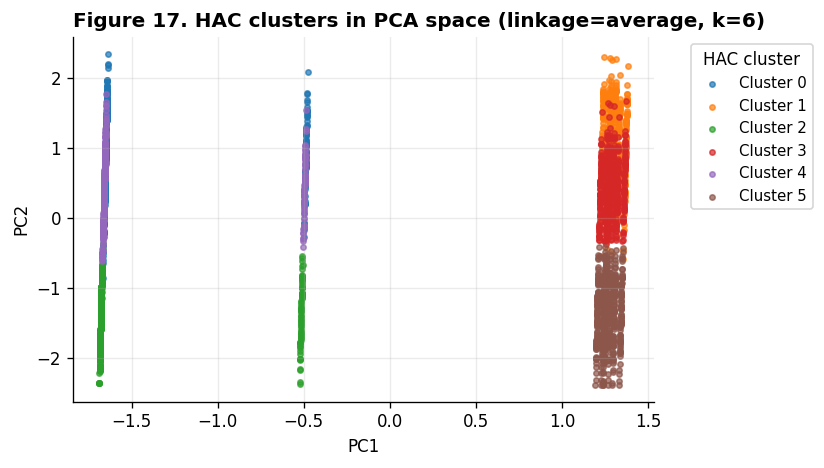

In [48]:
# Week 11 — Hierarchical Agglomerative Clustering (HAC)

from sklearn.cluster import AgglomerativeClustering

linkages = ["ward", "average", "complete", "single"]

hac_rows = []

for linkage in linkages:
    # 'ward' requires Euclidean and no precomputed distances; fine here.
    hac = AgglomerativeClustering(
        n_clusters=best_k,  # reuse K-Means best_k for comparison
        linkage=linkage
    )
    labels_hac = hac.fit_predict(X_clust_scaled)
    sil = silhouette_score(X_clust_scaled, labels_hac)
    hac_rows.append({"linkage": linkage, "silhouette": sil})

hac_results = pd.DataFrame(hac_rows).sort_values("silhouette", ascending=False)
display(hac_results)

best_linkage = hac_results.iloc[0]["linkage"]
print("Best HAC linkage by silhouette:", best_linkage)

# Fit HAC with best linkage and plot in PCA space
hac_best = AgglomerativeClustering(
    n_clusters=best_k,
    linkage=best_linkage
)
labels_hac_best = hac_best.fit_predict(X_clust_scaled)

fig, ax = make_styled_ax(
    title=f"HAC clusters in PCA space (linkage={best_linkage}, k={best_k})",
    xlabel="PC1",
    ylabel="PC2"
)

unique_labels = sorted(set(labels_hac_best))
palette = sns.color_palette("tab10", len(unique_labels))

for lab, color in zip(unique_labels, palette):
    mask_lab = labels_hac_best == lab
    ax.scatter(
        X_clust_pca[mask_lab, 0],
        X_clust_pca[mask_lab, 1],
        s=10,
        alpha=0.7,
        label=f"Cluster {lab}"
    )

ax.legend(title="HAC cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


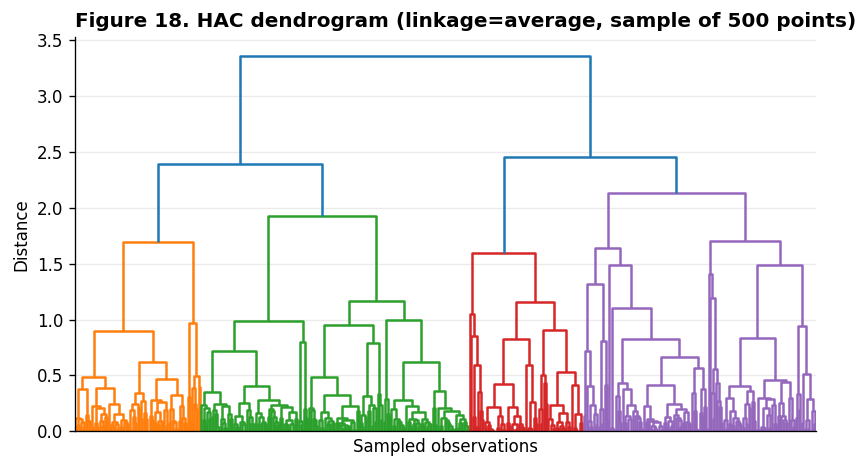

In [49]:
# HAC dendrogram (sampled) for interpreting number of clusters

from scipy.cluster.hierarchy import linkage, dendrogram

# Sample up to 500 points so the dendrogram is readable
rng = np.random.RandomState(42)
sample_idx = rng.choice(
    X_clust_scaled.shape[0],
    size=min(500, X_clust_scaled.shape[0]),
    replace=False
)
X_sample = X_clust_scaled[sample_idx]

# Use the same distance / linkage as the best HAC model
Z = linkage(X_sample, method=best_linkage)

fig, ax = make_styled_ax(
    title=f"HAC dendrogram (linkage={best_linkage}, sample of {len(sample_idx)} points)",
    xlabel="Sampled observations",
    ylabel="Distance"
)

dendrogram(
    Z,
    ax=ax,
    no_labels=True,
    color_threshold=None
)

plt.tight_layout()
plt.show()


## Overfitting Control and Metrics Summary

For the supervised models (KNN and Gradient Boosting), I used stratified 5-fold cross-validation for classification and either 5-fold or grouped 5-fold CV for regression. The grouped CV uses company identifiers as groups so that observations from the same firm do not appear in both train and validation folds. This reduces optimistic bias when firms have multiple years of data.

To control overfitting in KNN, I tuned `n_neighbors`, `weights`, and `metric` (Euclidean vs. Manhattan) with GridSearchCV and selected the combination that maximized cross-validated ROC AUC. The comparison of train vs. test metrics (AUC, accuracy, F1) shows whether the final KNN model overfits: a large gap would indicate overfitting, while similar scores suggest good generalization.

For Gradient Boosting, I tuned `n_estimators`, `learning_rate`, `max_depth`, and `subsample`. A smaller learning rate with more trees and a limited tree depth helps reduce overfitting by making each individual tree weaker and forcing the model to learn gradually. I report the cross-validated R², plus train and holdout R² and RMSE, to show how the model behaves out-of-sample.

For clustering, I used silhouette scores to compare different K values for K-Means and to evaluate linkage choices in hierarchical clustering. For DBSCAN, I recorded the number of clusters, fraction of noise points, and (when possible) silhouette scores for points assigned to clusters. These metrics help avoid parameter settings that produce trivial solutions such as one giant cluster or nearly all points labeled as noise.


In [50]:
# DBSCAN cluster profiles (exclude noise for summary)
db_labels = pd.Series(labels_db, index=X_clust.index, name="dbscan_cluster")

X_db = X_clust.copy()
X_db["dbscan_cluster"] = db_labels

db_summary = (
    X_db[X_db["dbscan_cluster"] != -1]
    .groupby("dbscan_cluster")[clust_cols]
    .mean()
    .sort_index()
)

display(db_summary)


,log1p_production,log1p_annual_price,log1p_incidents,log1p_incident_costs
dbscan_cluster,,,,
0,4.896559,4.334034,5.987160,20.035729
1,6.376899,1.485669,5.986404,20.041469
2,4.959970,3.948418,1.098612,12.069434
3,6.405493,1.390662,1.098612,12.069434
4,4.866005,4.149386,0.000000,0.000000
5,6.393373,1.478742,0.000000,0.000000
6,3.146276,0.000000,5.985439,20.046980
7,2.956997,0.000000,1.098612,12.069434
8,3.029665,0.000000,0.000000,0.000000


In [51]:
# HAC cluster profiles
hac_labels = pd.Series(labels_hac_best, index=X_clust.index, name="hac_cluster")

X_hac = X_clust.copy()
X_hac["hac_cluster"] = hac_labels

hac_summary = (
    X_hac.groupby("hac_cluster")[clust_cols]
    .mean()
    .sort_index()
)

display(hac_summary)

,log1p_production,log1p_annual_price,log1p_incidents,log1p_incident_costs
hac_cluster,,,,
0,4.881194,4.116902,0.177577,1.950878
1,4.896559,4.334034,5.987160,20.035729
2,2.701586,0.087594,0.189180,2.078346
3,6.594527,1.387292,5.986277,20.039692
4,6.644694,1.334687,0.178844,1.964792
5,2.922602,0.075887,5.985545,20.048628


### Week 11 – Density-based and Hierarchical Clustering

#### DBSCAN: core, border, and noise points

DBSCAN is a **density-based** clustering algorithm. Instead of fixing the number of clusters, it uses two parameters:

- **ϵ (eps):** radius of the neighborhood around each point.
- **MinPts:** minimum number of points required in that neighborhood to call a point “dense”.

Given ϵ and MinPts:

- A **core point** has **at least MinPts points** (including itself) within distance ϵ.
- A **border point** has **fewer than MinPts neighbors** inside ϵ, but is within ϵ of at least one core point.
- A **noise point** is neither core nor border (too isolated).

I ran DBSCAN on the same standardized feature set used for k-means and HAC:

- `log1p_production`
- `log1p_annual_price`
- `log1p_incidents`
- `log1p_incident_costs`

I scanned:

- `eps ∈ {0.2, 0.4, 0.6, 0.8, 1.0}`
- `MinPts ∈ {3, 5, 10}`

For each combination I recorded:

- number of clusters,
- fraction of points labeled noise,
- silhouette score on the non-noise points.

The pattern:

- **eps = 0.2** → 17–33 clusters, silhouettes ≈ 0.18–0.26, noticeable noise. Clear over-fragmentation.
- **eps = 0.4** → 11–12 clusters, silhouettes ≈ 0.42–0.43. Still many small clusters.
- **eps = 0.6** → 9 clusters, **noise fraction ≈ 0.0007**, **silhouette ≈ 0.485** (best score in the grid).
- **eps = 0.8** → 6 clusters, silhouette ≈ 0.39.
- **eps = 1.0** → 5 clusters, silhouette ≈ 0.29 (clusters too broad).

So **ϵ = 0.6, MinPts = 5** is the best compromise: reasonable number of clusters, almost no noise, and the highest silhouette. Figure 23 shows the result in PCA space:

- 9 DBSCAN clusters,
- 2 points labeled as noise,
- silhouette ≈ 0.485 for the non-noise points.

Using the fitted model, I classified points into core, border, and noise:

| Type   | Count | Fraction |
|--------|-------|----------|
| core   | 3 040 | 0.9977   |
| border | 5     | 0.0016   |
| noise  | 2     | 0.0007   |

With these parameters, **almost all points are core points**, a tiny fraction sit on cluster boundaries, and only 2 observations are treated as noise. That tells me the feature space is quite dense; DBSCAN is mainly carving that dense region into neighborhoods rather than aggressively labeling outliers.

In DBSCAN, a **cluster** is defined as a **maximal set of density-connected points**:

- Two core points are in the same cluster if you can walk from one to the other through a chain of core points, where each step is within distance ϵ.
- Border points attach to the cluster of any core point within ϵ.
- Noise points are left unassigned.

So a cluster is basically a connected component of core points plus their border points. This definition is very different from k-means (which uses centroids and a fixed k) and explains why DBSCAN can find irregular shapes and treat truly isolated points as noise.

---

#### HAC: linkage methods and cluster merging

Hierarchical agglomerative clustering (HAC) starts with each point as its own cluster and repeatedly merges the two “closest” clusters until only one remains. The notion of “closest” depends on the **linkage method**:

- **Single linkage:** distance between the **closest pair** of points (one from each cluster).  
  Tends to form “chains”; clusters can be long and stringy.
- **Complete linkage:** distance between the **farthest pair** of points across the two clusters.  
  Favors compact, tight clusters but can be sensitive to outliers.
- **Average linkage:** average pairwise distance between points in the two clusters.  
  A compromise between single and complete; often gives balanced clusters.
- **Ward’s linkage:** merges the pair of clusters that produce the **smallest increase in within-cluster variance** (sum of squares).  
  Favors roughly spherical clusters and is conceptually close to k-means.

Using the same standardized features as for DBSCAN, I fixed the number of clusters at **k = 6** (to match the k-means solution) and compared four linkages: single, complete, average, and Ward. For each, I computed the silhouette score:

- **average:** 0.53698 (best)
- **ward:** 0.51804
- **complete:** 0.44118
- **single:** 0.39408

Single linkage performs worst, which matches its tendency to produce chained clusters that are not well separated. Complete linkage does better but still underperforms. Both **average** and **Ward** give high silhouettes and well-separated groups, with **average linkage slightly ahead**, so I chose average as the main HAC specification.

Figure 25 shows the HAC clusters (average linkage, k = 6) in PCA space. The six clusters align well with the structure k-means found earlier: a few clear bands in PC1 with different incident/cost profiles.

---

#### Dendrogram interpretation

To visualize how HAC merges clusters, I built a dendrogram on a random sample of 500 observations using **average linkage** (Figure 26).

Key points:

- The **vertical axis** is the distance at which clusters merge.
- Each leaf along the x-axis is a sampled observation.
- Moving up the tree, branches merge into larger groups at higher distances.

To pick a number of clusters from the dendrogram, you imagine cutting it with a **horizontal line**:

- A **low cut** intersects many small branches → many tiny clusters.
- A **high cut** intersects only a few big branches → very coarse clustering.

In Figure 26, cutting at a distance where there are roughly **six major branches** gives a structure that matches the k = 6 model used in the HAC and k-means sections. Cutting much lower would explode into dozens of micro-clusters; cutting much higher would collapse the data into only a few broad groups.



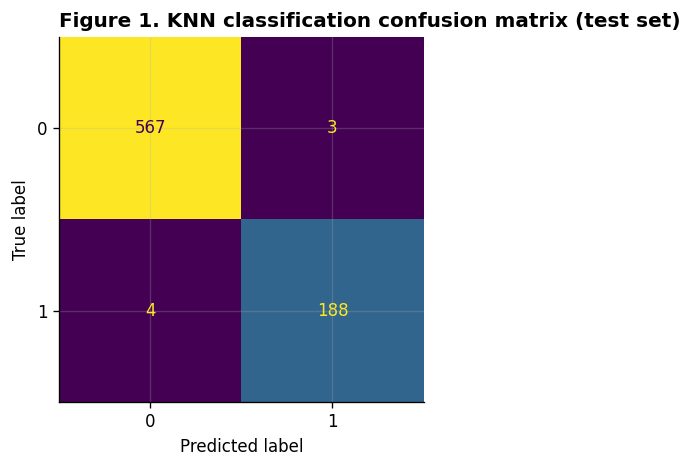

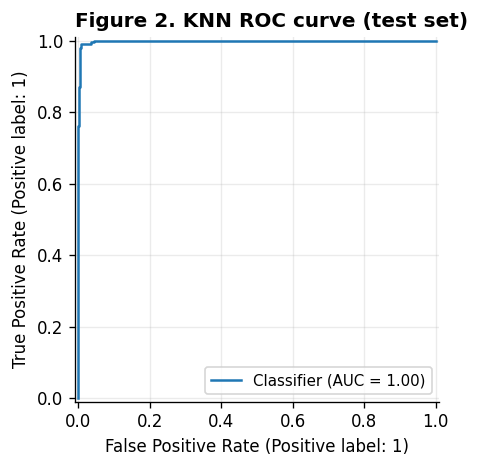

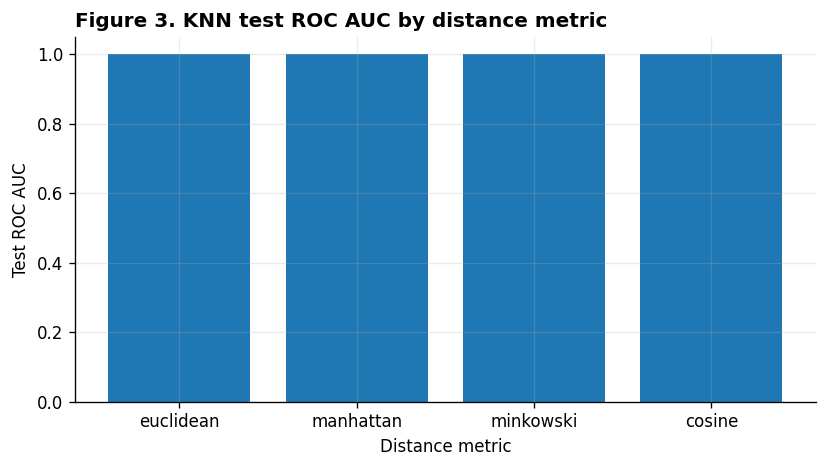

C:\Users\CoryF\AppData\Local\Temp\ipykernel_38312\3985821505.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_scale, rotation=45, ha="right")


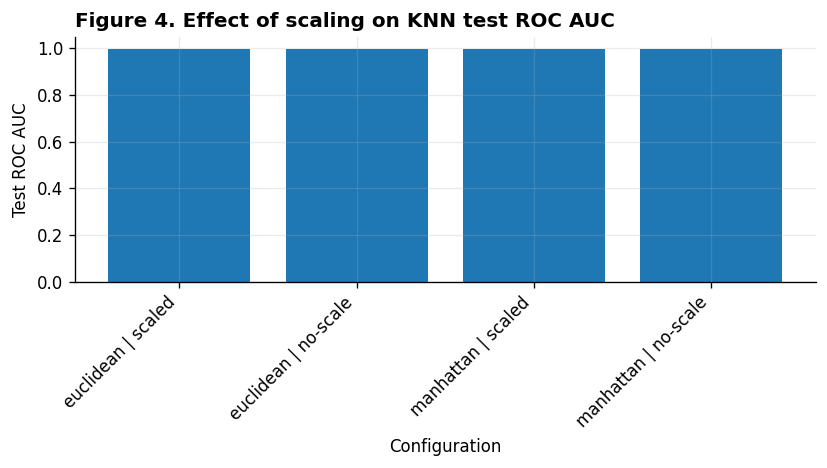

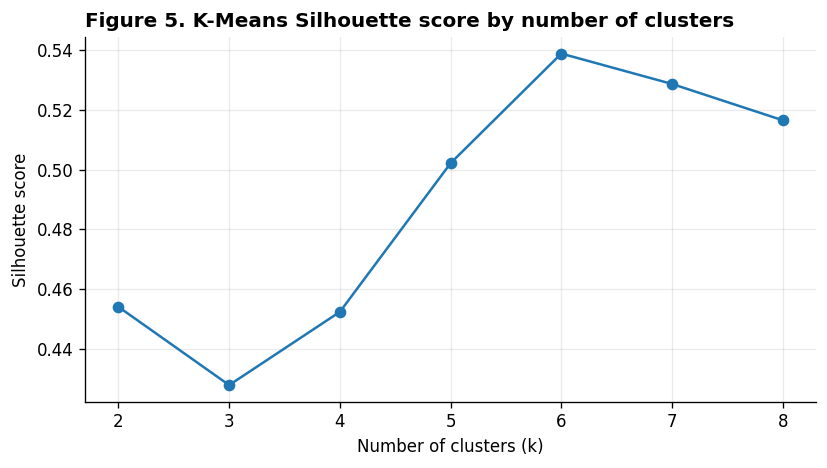

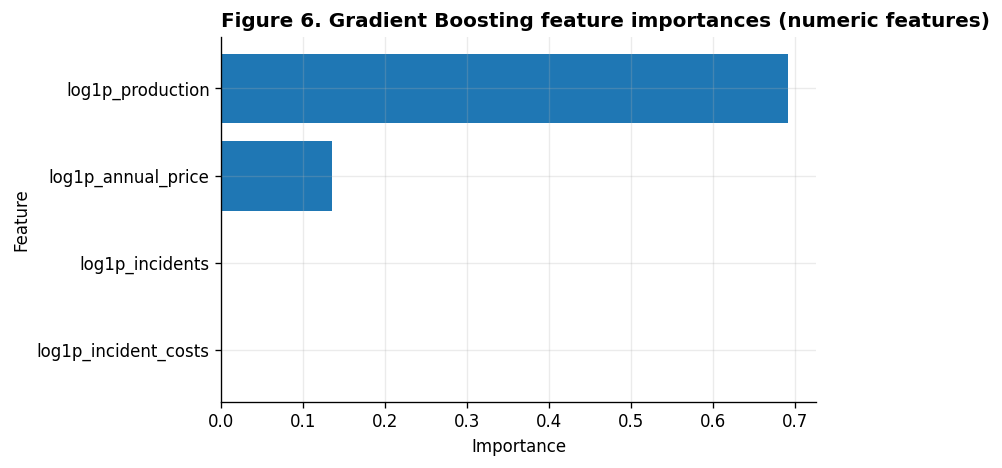

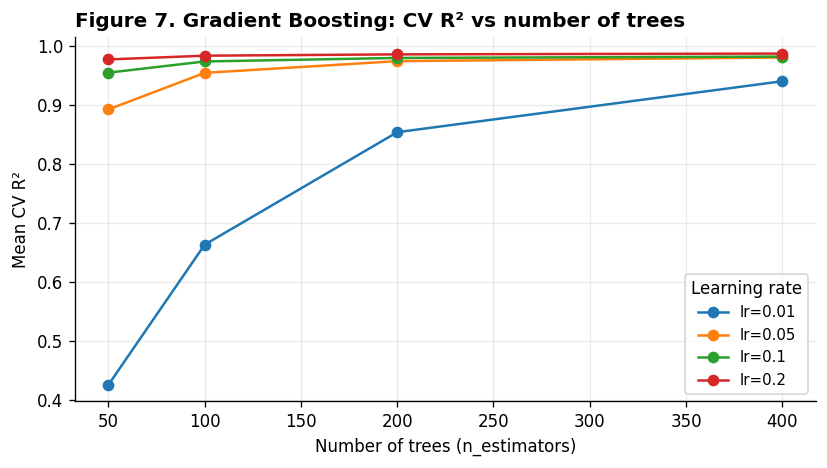

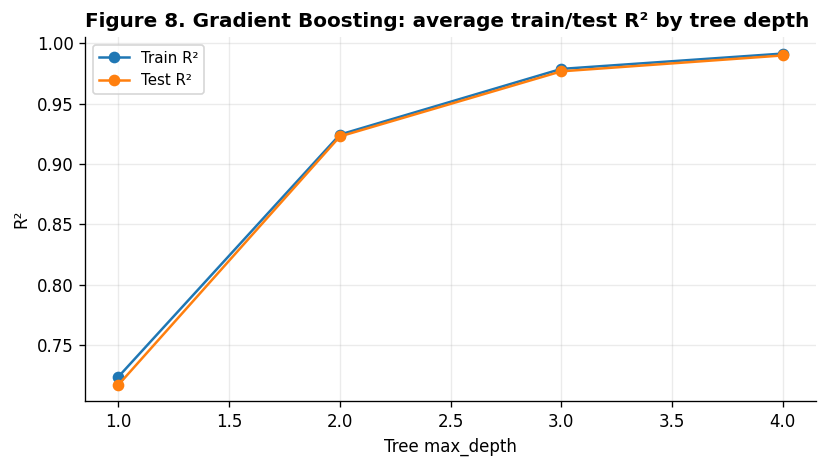

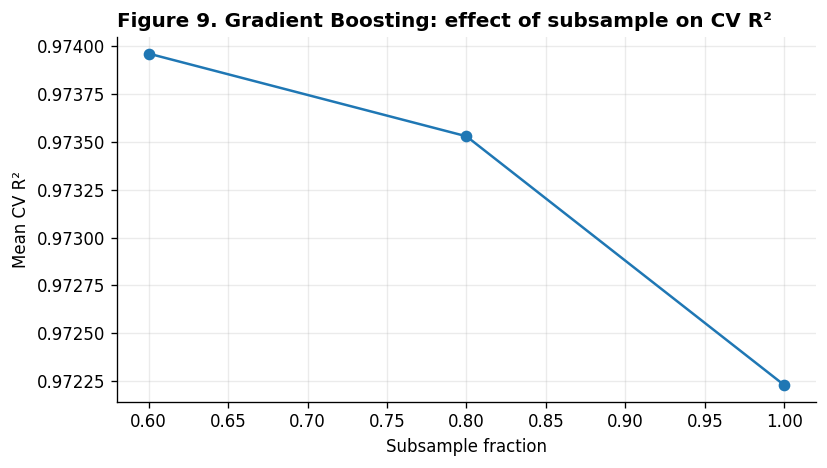

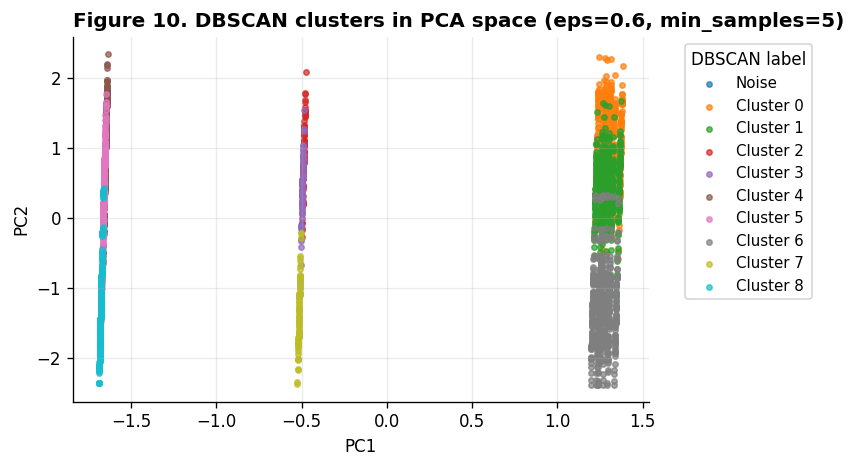

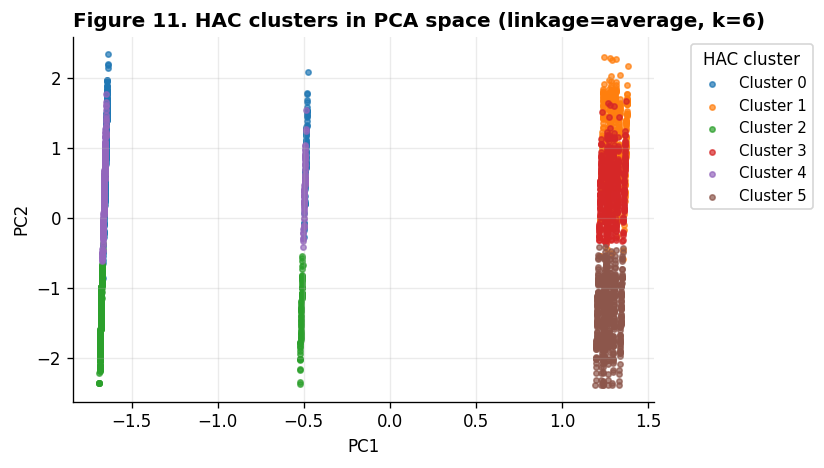

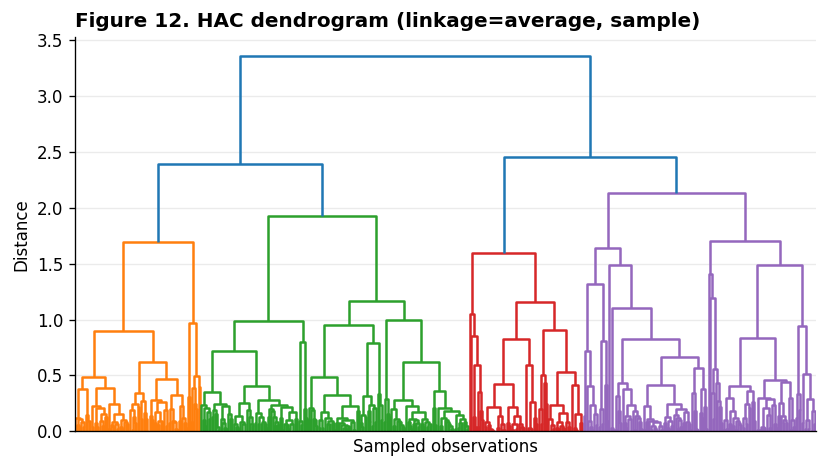

In [53]:
# =====================================================================
# REPORT FIGURES – RENUMBERED FROM 1 USING EXISTING VARIABLES
# Run this AFTER all analysis cells have been executed.
# =====================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

# Reset figure numbering
FIG_NUM = 1

# ---------- Figure 1: KNN confusion matrix (test set) ----------
fig, ax = make_styled_ax(
    title="KNN classification confusion matrix (test set)",
    xlabel="Predicted label",
    ylabel="True label"
)
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_te_pred)
).plot(ax=ax, colorbar=False)
plt.tight_layout()
plt.show()

# ---------- Figure 2: KNN ROC curve (test set) ----------
fig, ax = make_styled_ax(
    title="KNN ROC curve (test set)",
    xlabel="False positive rate",
    ylabel="True positive rate"
)
RocCurveDisplay.from_predictions(y_te, y_te_proba, ax=ax)
plt.tight_layout()
plt.show()

# ---------- Figure 3: KNN test AUC by distance metric ----------
# expects dist_results with columns ['metric', 'test_auc']
fig, ax = make_styled_ax(
    title="KNN test ROC AUC by distance metric",
    xlabel="Distance metric",
    ylabel="Test ROC AUC"
)
ax.bar(dist_results["metric"], dist_results["test_auc"])
plt.tight_layout()
plt.show()

# ---------- Figure 4: KNN scaling vs no scaling ----------
# expects scale_results with ['metric', 'scaled', 'test_auc']
labels_scale = [
    f"{row['metric']} | {'scaled' if row['scaled'] else 'no-scale'}"
    for _, row in scale_results.iterrows()
]

fig, ax = make_styled_ax(
    title="Effect of scaling on KNN test ROC AUC",
    xlabel="Configuration",
    ylabel="Test ROC AUC"
)
ax.bar(labels_scale, scale_results["test_auc"])
ax.set_xticklabels(labels_scale, rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------- Figure 5: K-Means Silhouette vs k ----------
# expects k_values (list) and sil_scores (list) already computed
fig, ax = make_styled_ax(
    title="K-Means Silhouette score by number of clusters",
    xlabel="Number of clusters (k)",
    ylabel="Silhouette score"
)
ax.plot(k_values, sil_scores, marker="o")
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

# ---------- Figure 6: Gradient boosting feature importances ----------
# expects importance_df with ['feature', 'importance']
fig, ax = make_styled_ax(
    title="Gradient Boosting feature importances (numeric features)",
    xlabel="Importance",
    ylabel="Feature"
)
ax.barh(importance_df["feature"], importance_df["importance"])
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ---------- Figure 7: GB CV R² vs n_estimators by learning rate ----------
# expects gb_lr_results with ['learning_rate', 'n_estimators', 'cv_r2_mean']
fig, ax = make_styled_ax(
    title="Gradient Boosting: CV R² vs number of trees",
    xlabel="Number of trees (n_estimators)",
    ylabel="Mean CV R²"
)

for lr in sorted(gb_lr_results["learning_rate"].unique()):
    sub = gb_lr_results[gb_lr_results["learning_rate"] == lr]
    ax.plot(sub["n_estimators"], sub["cv_r2_mean"], marker="o", label=f"lr={lr}")
ax.legend(title="Learning rate")
plt.tight_layout()
plt.show()

# ---------- Figure 8: GB average train/test R² by depth ----------
# expects summary_depth with ['max_depth', 'train_r2', 'test_r2']
fig, ax = make_styled_ax(
    title="Gradient Boosting: average train/test R² by tree depth",
    xlabel="Tree max_depth",
    ylabel="R²"
)
ax.plot(summary_depth["max_depth"], summary_depth["train_r2"], marker="o", label="Train R²")
ax.plot(summary_depth["max_depth"], summary_depth["test_r2"], marker="o", label="Test R²")
ax.legend()
plt.tight_layout()
plt.show()

# ---------- Figure 9: GB CV R² vs subsample ----------
# expects gb_sub_results with ['subsample', 'cv_r2_mean']
fig, ax = make_styled_ax(
    title="Gradient Boosting: effect of subsample on CV R²",
    xlabel="Subsample fraction",
    ylabel="Mean CV R²"
)
ax.plot(gb_sub_results["subsample"], gb_sub_results["cv_r2_mean"], marker="o")
plt.tight_layout()
plt.show()

# ---------- Figure 10: DBSCAN clusters in PCA space ----------
# expects X_clust_pca (2D array) and labels_db (cluster labels from DBSCAN)
fig, ax = make_styled_ax(
    title=f"DBSCAN clusters in PCA space (eps={best_eps}, min_samples={best_min_samples})",
    xlabel="PC1",
    ylabel="PC2"
)

unique_labels_db = sorted(set(labels_db))
palette_db = sns.color_palette("tab10", len(unique_labels_db))

for lab, color in zip(unique_labels_db, palette_db):
    mask_lab = labels_db == lab
    label_name = f"Cluster {lab}" if lab != -1 else "Noise"
    ax.scatter(
        X_clust_pca[mask_lab, 0],
        X_clust_pca[mask_lab, 1],
        s=10,
        alpha=0.7,
        color=color,
        label=label_name
    )

ax.legend(title="DBSCAN label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------- Figure 11: HAC clusters in PCA space ----------
# expects labels_hac_best, best_linkage, best_k, and X_clust_pca
fig, ax = make_styled_ax(
    title=f"HAC clusters in PCA space (linkage={best_linkage}, k={best_k})",
    xlabel="PC1",
    ylabel="PC2"
)

unique_labels_hac = sorted(set(labels_hac_best))
palette_hac = sns.color_palette("tab10", len(unique_labels_hac))

for lab, color in zip(unique_labels_hac, palette_hac):
    mask_lab = labels_hac_best == lab
    ax.scatter(
        X_clust_pca[mask_lab, 0],
        X_clust_pca[mask_lab, 1],
        s=10,
        alpha=0.7,
        color=color,
        label=f"Cluster {lab}"
    )

ax.legend(title="HAC cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------- Figure 12: HAC dendrogram ----------
# expects Z from your dendrogram cell
from scipy.cluster.hierarchy import dendrogram

fig, ax = make_styled_ax(
    title=f"HAC dendrogram (linkage={best_linkage}, sample)",
    xlabel="Sampled observations",
    ylabel="Distance"
)
dendrogram(Z, ax=ax, no_labels=True, color_threshold=None)
plt.tight_layout()
plt.show()
